<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.891 · Aprendizaje automático · PEC2</p>
<p style="margin: 0; text-align:right;">2025-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 2: Métodos no supervisados

En esta práctica exploraremos el <strong>aprendizaje no supervisado</strong> con un caso real: el análisis y agrupamiento de miles de recetas. A partir de datos textuales y de ingredientes, crearemos distintas representaciones (desde <strong><em>embeddings</em> semánticos de modelos de lenguaje</strong> hasta vectores <strong><em>one-hot</em></strong>) para descubrir patrones sin etiquetas. Usaremos <strong>UMAP</strong> para reducir dimensionalidad y distintas técnicas de <strong><em>clustering</em></strong> para segmentar, observando cómo la elección de representación y métrica de distancia condiciona las estructuras detectadas y su interpretación.

La PEC consta de dos ejercicios:

 - **Clustering con distintas estrategias**: k-means y regla del codo, basadas en densidad y jerárquicas.
 - **Aplicación**: clustering y reducción de dimensionalidad culinaria, distintas maneras de descubrir grupos de recetas en base a sus metadatos.

**Importante**: cada uno de los ejercicios puede suponer varios minutos de ejecución, por lo que la entrega debe hacerse en formato notebook y en formato html, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a html desde el menú File → Download as → HTML.

**Importante**: existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de cada PEC. Para cambiar el tipo de celda a este tipo, elegid en el menú: Cell → Cell Type → Markdown.

**Importante**: la solución planteada no debe utilizar métodos, funciones o parámetros declarados "deprecated" en futuras versiones.

**Importante**: es conveniente que utilicéis una semilla con un valor fijo (en este Notebook se os propone la variable seed inicializada a 100) en todos aquellos métodos o funciones que contengan alguna componente aleatoria para aseguraros de que obtendréis siempre el mismo resultado en las distintas ejecuciones de vuestro código.

**Importante**: si la ejecución de una celda toma más de 20 minutos puedes reducir el número de filas del dataframe para agilizar el proceso.

**Importante**: no olvidéis poner vuestro nombre y apellidos en la siguiente celda.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Nombre y apellidos: JULIO UBEDA QUESADA</strong>
</div>

---

Para ello vamos a necesitar las siguientes librerías:

In [1]:
import ast
from collections import Counter
import random

import hdbscan
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform, cdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sentence_transformers import SentenceTransformer
from sklearn import cluster
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth, AgglomerativeClustering
from sklearn import datasets
from sklearn import manifold
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.metrics.pairwise import cosine_distances, euclidean_distances
from sklearn.preprocessing import MultiLabelBinarizer
import tqdm
import umap.umap_ as umap

## 1. Métodos de *clustering* (4 puntos)

Este ejercicio trata de explorar distintas técnicas de agrupamiento ajustándolas a distintos conjuntos de datos.

El objetivo es doble: entender la influencia de los parámetros en su comportamiento, y conocer sus limitaciones en la búsqueda de estructuras de datos.

### Generación de los conjuntos de datos

In [2]:
X_blobs, y_blobs = datasets.make_blobs(n_samples=1000, n_features=2, centers=4, cluster_std=1.6, random_state=42)
X_moons, y_moons = datasets.make_moons(n_samples=1000, noise=.07, random_state=42)
X_circles, y_circles = datasets.make_circles(n_samples=1000, factor=.5, noise=.05, random_state=42)

Cada dataset tiene 2 variables: una variable *X* que contiene 2 features (columnas) y tantas filas como muestras. Y una variable *y* que alberga las etiquetas que identifican cada cluster.

A lo largo del ejercicio no se usará la variable *y* (sólo con el objetivo de visualizar). El objetivo es a través de los distintos modelos de *clustering* conseguir encontrar las estructuras descritas por las variables *y*.

C:\Users\jubeda2\AppData\Local\Temp\ipykernel_20412\339150881.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X[:,0], X[:,1], s=15, c='gray', alpha=.3, cmap='jet')


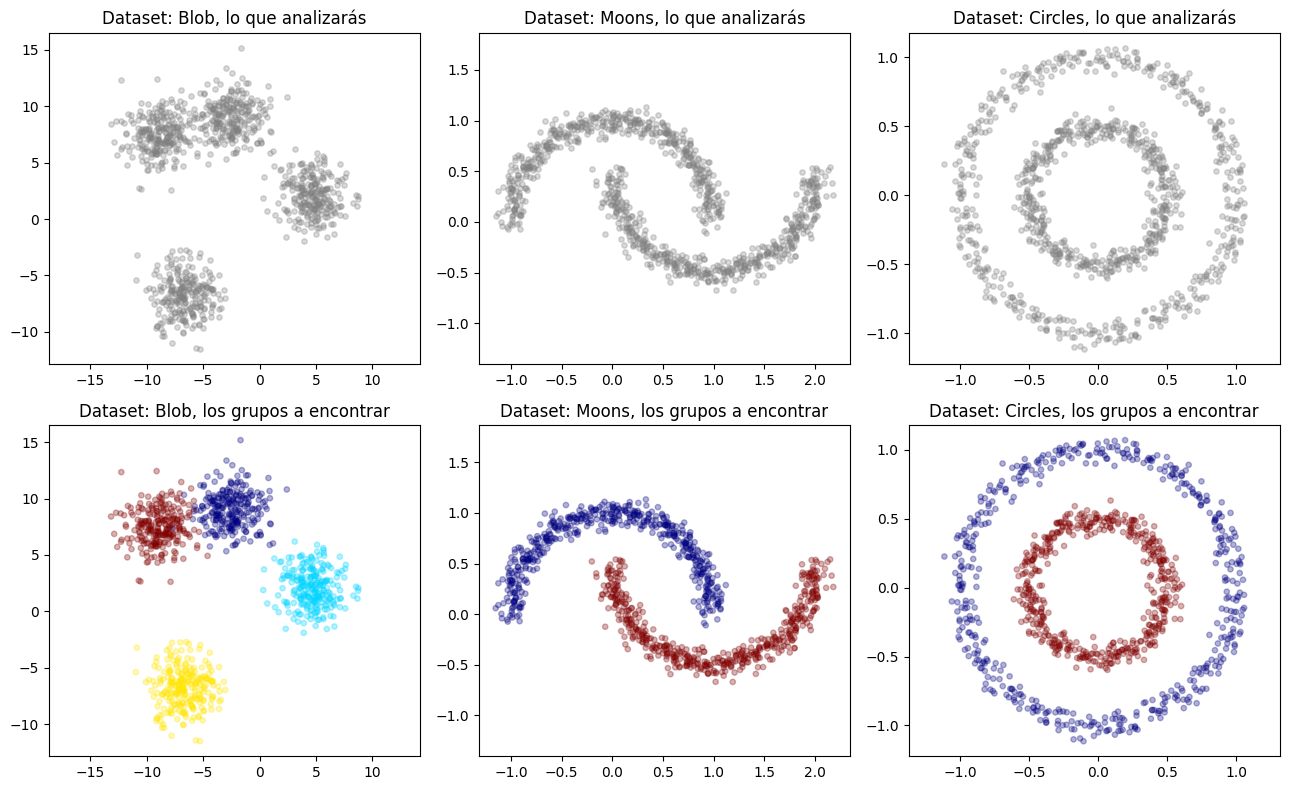

In [3]:
fig, axis = plt.subplots(2, 3, figsize=(13, 8))
for i, (X, y, ax, name) in enumerate(zip([X_blobs, X_moons, X_circles] * 2,
                                         [None] * 3 + [y_blobs, y_moons, y_circles],
                                         axis.reshape(-1),
                                         ['Blob', 'Moons', 'Circles'] * 2)):
    ax.set_title('Dataset: {}, '.format(name) + ('lo que analizarás' if i < 3 else 'los grupos a encontrar'))
    if y is not None:
        ax.scatter(X[:,0], X[:,1], s=15, c=y, alpha=.3, cmap='jet')
    else:
        ax.scatter(X[:,0], X[:,1], s=15, c='gray', alpha=.3, cmap='jet')
    ax.axis('equal')
plt.tight_layout()

### 1 a. K-means

En este apartado se pide probar el algoritmo *k-means* sobre los tres datasets presentados anteriormente ajustando con los parámetros adecuados y analizar sus resultados.

In [4]:
X, y = X_blobs, y_blobs

Para estimar el número de clusters a detectar por *k-means*. Una técnica para estimar $k$ es, como se explica en la teoría:
> Los criterios anteriores (minimización de distancias intra grupo o maximización de distancias inter grupo) pueden usarse para establecer un valor adecuado para el parámetro k. Valores k para los que ya no se consiguen mejoras significativas en la homogeneidad interna de los segmentos o la heterogeneidad entre segmentos distintos, deberían descartarse.

Lo que popularmente se conocer como *regla del codo*.

Primero es necesario calcular la suma de los errores cuadráticos ([*SSE*](https://bl.ocks.org/rpgove/0060ff3b656618e9136b)) que consiste en la suma de todos los errores (distancia de cada punto a su centroide asignado) al cuadrado.

$$SSE = \sum_{i=1}^{K} \sum_{x \in C_i} euclidean(x, c_i)^2$$

Donde $K$ es el número de clusters a buscar por *k-means*, $x \in C_i$ son los puntos que pertenecen a i-ésimo cluster, $c_i$ es el centroide del cluster $C_i$ (al que pertenece el punto $x$), y $euclidean$ es la [distancia euclídea](https://en.wikipedia.org/wiki/Euclidean_distance).

Este procedimiento realizado para cada posible valor $k$, resulta en una función monótona decreciente, donde el eje $x$ representa los distintos valores de $k$, y el eje $y$ el $SSE$. Intuitivamente se podrá observar un significativo descenso del error, que indicará el valor idóneo de $k$.

**Se pide realizar la representación gráfica de la regla del codo junto a su interpretación, utilizando la librería ```matplotlib``` y la implementación en scikit-learn de [*k-means*](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).**

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Blobs.
</div>

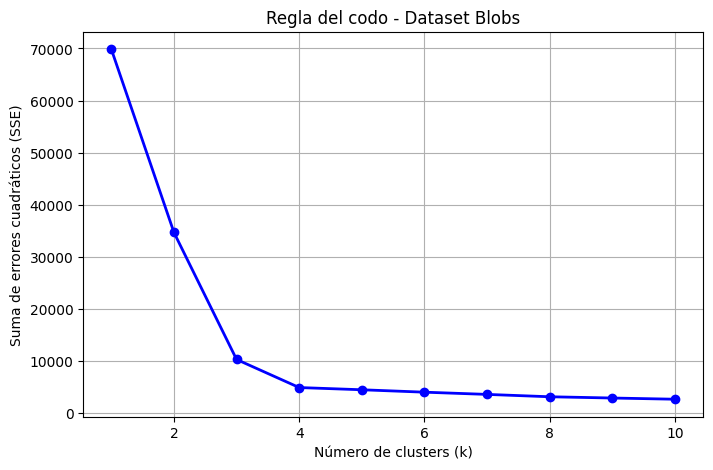

In [5]:
# =============================================================
# Cálculo y visualización de la regla del codo
# =============================================================

# Semilla para reproducibilidad
seed = 100

# Rango de posibles valores de k
k_values = range(1, 11)

# Lista para almacenar los valores SSE (inertia_ en sklearn)
sse = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)  # inertia_ = suma de distancias cuadradas (SSE)

# Representación gráfica
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, 'bo-', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Suma de errores cuadráticos (SSE)')
plt.title('Regla del codo - Dataset Blobs')
plt.grid(True)
plt.savefig(r'../Visualizaciones/regla_del_codo_blobs.png', dpi=300)
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

La gráfica muestra la **Suma de Errores Cuadráticos (SSE)** en función del número de clusters ($k$). Se observa:

- **Decrecimiento pronunciado**: Entre $k$ = 1 y $k$ = 4, el SSE disminuye drásticamente (de ~70,000 a ~5,000).
- **"Codo" en $k$ = 4:** A partir de $k$ = 4, la reducción del error se vuelve mucho más gradual y marginal.
- **Estabilización**: Desde $k$ = 5 en adelante, la mejora es prácticamente imperceptible.

Por lo tanto, el punto óptimo está claramente en **$k$ = 4**, ya que añadir más clusters no proporciona una reducción significativa del error. Este es el "codo" de la curva, donde se equilibra la complejidad del modelo con la calidad del agrupamiento.

Además de la regla del codo, se podría utilizar:

- **Método del Silhouette Score**: Mide qué tan bien está asignado cada punto a su cluster comparado con otros clusters (valores entre -1 y 1, siendo 1 óptimo).
- **Método de Gap Statistic**: Compara la SSE observada con la esperada bajo una distribución de referencia aleatoria.

> Estos dos últimos métodos se pueden revisar más a fondo en: https://openaccess.uoc.edu/server/api/core/bitstreams/859ca353-d4f7-4448-a284-6454decfc950/content

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Blobs.
</div>

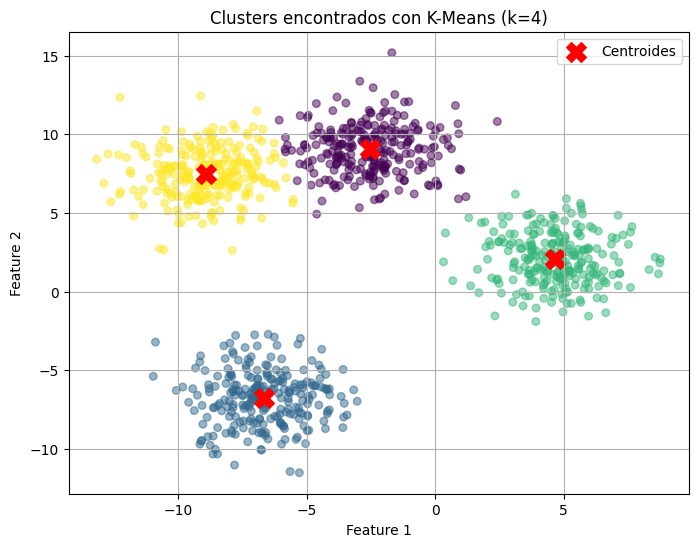

In [6]:
# ==========================================================
# Cálculo y visualización de los grupos
# ==========================================================

# Aplicamos KMeans con el k óptimo (4)
k_optimo = 4
kmeans = KMeans(n_clusters=k_optimo, random_state=seed)
y_pred = kmeans.fit_predict(X)

# Obtenemos los centroides
centroides = kmeans.cluster_centers_

# Visualización de los clusters encontrados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis', alpha=0.5)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Clusters encontrados con K-Means (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.savefig(r'../Visualizaciones/clusters_kmeans_blobs.png', dpi=300)
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

`K-Means` ha identificado **4 clusters bien diferenciados**:

- **Cluster amarillo** (arriba-izquierda): ~(-9, 7).
- **Cluster morado** (centro-arriba): ~(-2, 9).
- **Cluster verde** (derecha-centro): ~(5, 2). 
- **Cluster azul** (abajo-izquierda): ~(-7, -7).

Los centroides (marcas rojas en X) están bien posicionados en el centro de cada agrupación natural de puntos.

El algoritmo `K-Means` ha funcionado **excepcionalmente bien** en este caso por varios motivos:

- **Separación clara**: Los clusters tienen una separación espacial evidente, con poca o ninguna superposición entre grupos
- **Forma esférica**: Los clusters son aproximadamente circulares/esféricos, lo cual es ideal para `K-Means` (que asume distancias euclidianas y clusters convexos)
- **Tamaños similares**: Los 4 clusters tienen aproximadamente el mismo número de puntos, lo que evita que `K-Means` favorezca clusters más grandes
- **Densidad homogénea**: La densidad de puntos dentro de cada cluster es relativamente uniforme
- **Dataset sintético "Blobs"**: Este dataset fue generado específicamente con `make_blobs`, diseñado para crear clusters gaussianos bien separados (el escenario ideal para `K-Means`).

Por lo tanto, `K-Means` es perfecto para este tipo de datos. En casos reales con clusters de formas irregulares, densidades variables o con ruido, otros algoritmos como `DBSCAN` o *clustering* jerárquico podrían ser más apropiados.

In [7]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Moons.
</div>

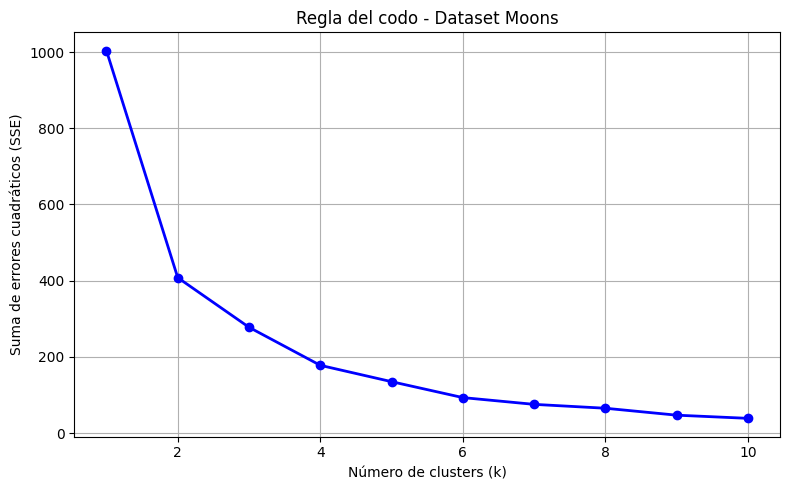

In [8]:
# ==========================================================
# Regla del codo - Dataset Moons
# ==========================================================

# Rango de valores posibles para k
k_values = range(1, 11)
sse = []

# Calcular SSE para cada k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Graficar la regla del codo
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, 'bo-', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Suma de errores cuadráticos (SSE)')
plt.title('Regla del codo - Dataset Moons')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/regla_del_codo_moons.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

La gráfica muestra un comportamiento muy diferente al caso de "blobs":

- **Decrecimiento continuo suave**: El SSE disminuye de forma gradual desde $k$ = 1 (~1000) hasta $k$=10 (~40).
- **Sin "codo" claro**: No hay un punto de inflexión obvio donde la mejora se estabilice dramáticamente.
- **Ambigüedad**: Podríamos considerar  $k$ = 2, $k$ = 3 o $k$ = 4 como posibles "codos" débiles.
- **Reducción significativa hasta $k$=4**: La mayor parte de la reducción ocurre entre $k$ = 1 y $k$ = 4.

La ausencia de un codo claro es una señal de alarma que indica que `K-Means` no es apropiado para este tipo de datos. La estructura subyacente no consiste en clusters esféricos/convexos.

Por lo tanto para este dataset específico podría mejorarse la eleccion de $k$:

- **Silhouette Score**: Probablemente mostraría valores bajos incluso para $k$ = 2, confirmando que `K-Means` no captura bien la estructura.
- **Inspección visual previa**: Una simple visualización 2D revelaría inmediatamente que los datos tienen forma de "lunas" no convexas.

Con todo esto, el analista deberia  **considerar otros algoritmos** puesto que la regla del codo sugiere que quizás no deberíamos usar `K-Means`

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Moons.
</div>

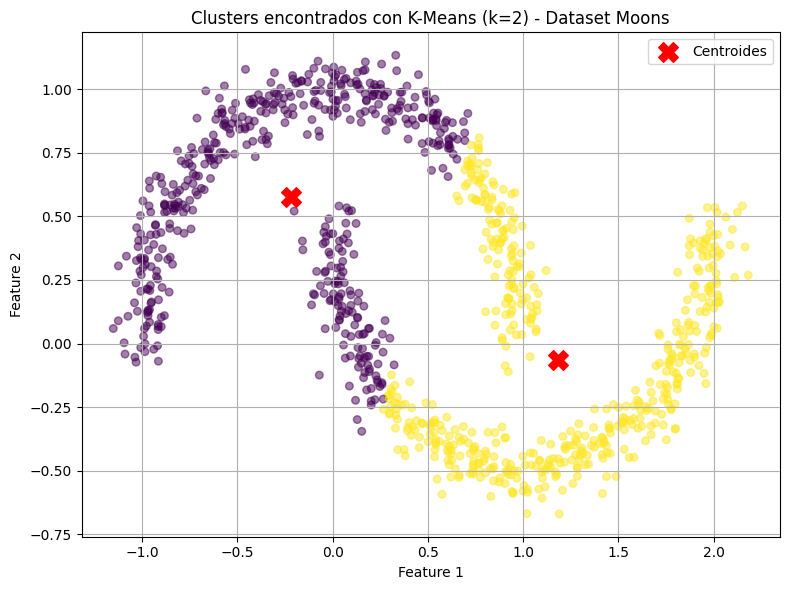

In [9]:
# ==========================================================
# Visualización de clusters - Dataset Moons
# ==========================================================

# Suponemos que la regla del codo sugiere k=2 (aunque K-means no agrupa bien este dataset)
k_optimo = 2

kmeans = KMeans(n_clusters=k_optimo, random_state=seed)
y_pred = kmeans.fit_predict(X)
centroides = kmeans.cluster_centers_

# Visualización de los clusters encontrados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis', alpha=0.5)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Clusters encontrados con K-Means (k=2) - Dataset Moons')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/clusters_kmeans_moons.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

`K-Means` con $k$ = 2 ha producido un resultado **para nada satisfactorio**:

- **Cluster morado**: Agrupa la parte superior de ambas lunas + parte de la izquierda.
- **Cluster amarillo**: Agrupa la parte inferior/derecha de ambas lunas.
- **División artificial**: Los centroides están posicionados en (~-0.3, 0.6) y (~1.2, -0.1), dividiendo el espacio de forma lineal/vertical, no siguiendo las formas naturales.

Con la imagen superior se observa por tanto que la estructura real del dataset son dos lunas entrelazadas (semicírculos cóncavos), pero `K-Means` ha creado una división casi vertical que corta transversalmente ambas lunas.

Las razones fundamentales son las limitaciones inherentes de `K-Means`:
1. **Asunción de convexidad**: `K-Means` asume que los clusters son convexos (formas que se pueden "abrazar" con una línea recta sin salirse). Las lunas son cóncavas y tienen forma de media luna, violando completamente esta asunción.
2. **Uso de distancia euclidiana**: `K-Means` asigna puntos al centroide más cercano usando distancia euclidiana (línea recta). En este caso:
   - Puntos en el **centro del espacio** están equidistantes de ambas lunas.
   - La decisión se vuelve arbitraria y se basa en la posición de los centroides iniciales
   - No captura la **conectividad topológica** de las lunas.

3. **Fronteras lineales**: Las fronteras de decisión de `K-Means` son hiperplanos (líneas rectas en 2D). Es imposible separar dos lunas entrelazadas con una línea recta.
4. **Optimización basada en centroides**: El algoritmo minimiza la distancia cuadrática a centroides, lo que favorece clusters esféricos de tamaño similar. Las lunas tienen forma alargada y curvada.

> Fuente [Tecnicas de clustering](https://openaccess.uoc.edu/server/api/core/bitstreams/859ca353-d4f7-4448-a284-6454decfc950/content)

In [10]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de la regla del codo en el dataset Circles.
</div>

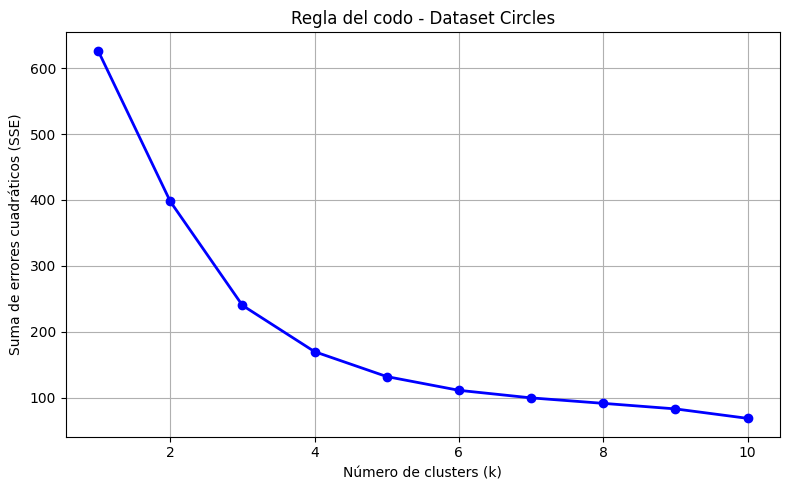

In [11]:
# ==========================================================
# Regla del codo - Dataset Circles
# ==========================================================

# Rango de valores posibles para k
k_values = range(1, 11)
sse = []

# Calcular SSE (inercia) para cada k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(X_circles)
    sse.append(kmeans.inertia_)

# Graficar la regla del codo
plt.figure(figsize=(8, 5))
plt.plot(k_values, sse, 'bo-', linewidth=2)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Suma de errores cuadráticos (SSE)')
plt.title('Regla del codo - Dataset Circles')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/regla_del_codo_circles.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué se interpreta en la gráfica? ¿Cómo podría mejorarse la elección de $k$?.  
</div>

La curva del codo muestra:

- **Decrecimiento continuo y gradual**: El SSE disminuye suavemente desde ~625 ($k$ = 1) hasta ~65 ($k$ = 10).
- **Sin codo definido**: Similar al caso "moons", no hay un punto de inflexión claro.
- **Posible "codo débil" en $k$ = 2-3**: Hay una ligera disminución de la pendiente alrededor de $k$ = 2, pero continúa bajando significativamente después.
- **Reducción sostenida**: La mejora continúa incluso hasta $k$ = 7-8, lo cual es sospechoso.

Por lo tanto, la ausencia de un codo pronunciado es otra señal de advertencia. Si tuviera que elegir basándome solo en esta gráfica, $k$ = 2 podría parecer razonable (lo cual tiene sentido conceptualmente: círculo interior vs exterior), pero la curva sugiere que `K-Means` está luchando para encontrar una estructura natural.

Una vez más, para este dataset podría mejorarse la eleccion de $k$ usando:

- **Silhouette Score**: Probablemente mostraría valores muy bajos para k=2, indicando que los clusters están mal definidos o se superponen según la métrica de K-Means
- **Visualización exploratoria**: Una simple gráfica 2D revelaría inmediatamente la estructura de círculos concéntricos

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Cálculo y visualización de los grupos en el dataset Circles.
</div>

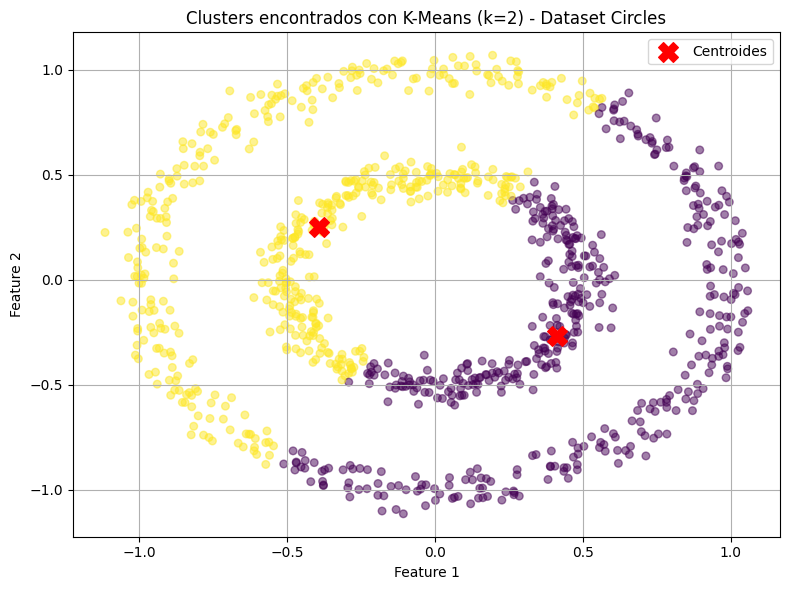

In [12]:
# ==========================================================
# Visualización de clusters - Dataset Circles
# ==========================================================

# La regla del codo podría sugerir k=2 (pero no representa bien los círculos)
k_optimo = 2

kmeans = KMeans(n_clusters=k_optimo, random_state=seed)
y_pred = kmeans.fit_predict(X)
centroides = kmeans.cluster_centers_

# Visualización de los clusters encontrados
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, s=30, cmap='viridis', alpha=0.5)
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.title('Clusters encontrados con K-Means (k=2) - Dataset Circles')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/clusters_kmeans_circles.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

`K-Means` con $k$ = 2 ha producido un resultado **desastroso y completamente incorrecto**:

- **Cluster amarillo** (izquierda): Agrupa aproximadamente la mitad izquierda de ambos círculos.
- **Cluster morado** (derecha): Agrupa aproximadamente la mitad derecha de ambos círculos.
- **División vertical**: Los centroides están en aproximadamente (-0.4, 0.25) y (0.4, -0.25), creando una partición vertical/diagonal del espacio.
- **Estructura real ignorada**: El algoritmo ha ignorado que hay un círculo pequeño interior y un anillo exterior.

Mientras que la **estructura real** consiste en dos círculos concéntricos (uno pequeño centrado en el origen y un anillo exterior), `K-Means` los ha cortado verticalmente como si fueran una pizza.

Este es el peor caso posible para K-Means. Las razones son:
1. **Imposibilidad geométrica con distancia euclidiana**: K-Means usa distancia euclidiana desde centroides. Es decir, si se considera un punto en el círculo interior:
   - Su distancia a cualquier punto del círculo exterior puede ser similar o menor que la distancia a otro punto del círculo interior en el lado opuesto
   - Los dos centroides encontrados están aproximadamente equidistantes de muchos puntos en ambos círculos
   - Por lo que, no hay forma de separar círculos concéntricos usando solo distancia euclidiana desde dos puntos centrales
2. **Estructura no convexa y anidada**: `K-Means` solo puede crear regiones mediante hiperplanos divisores (fronteras lineales), lo cual es imposible para círculos concéntricos y anidados.
3. **Centroides mal posicionados**: Los centroides de `K-Means` se posicionan en el centro de masa de los puntos asignados, lo cual minimiza el SSE global pero no captura la estructura real.
4. **Falsa simetría**: La distribución es radialmente simétrica, por lo que cualquier división lineal que pase por el centro tiene un SSE similar. Esto es por que, `K-Means` converge a una de estas divisiones arbitrarias basándose en la inicialización aleatoria.

### 1 b. Algoritmos basados en densidad: DBScan

En este apartado se pide aplicar clustering por densidad como [DBSCAN](https://en.wikipedia.org/wiki/DBSCAN) a los datasets anteriores para detectar los grupos subyacentes.

In [13]:
X, y = X_blobs, y_blobs

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="http://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html">DBSCAN en scikit-learn</a> jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Blobs.
</div>

DBSCAN - Blobs: 2 clusters detectados, 10 outliers


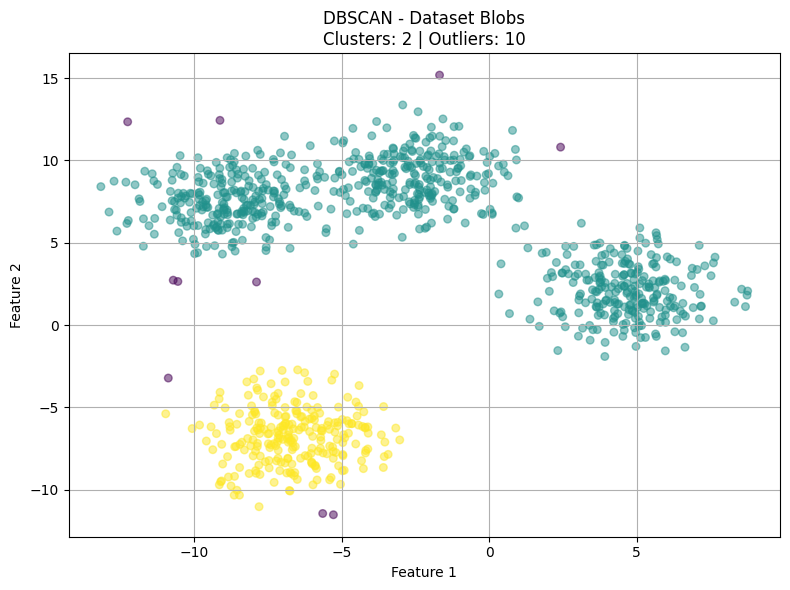

In [14]:
# ==========================================================
# DBSCAN - Dataset Blobs
# ==========================================================

# Ajustamos DBSCAN según dispersión
dbscan_blobs = DBSCAN(eps=1.5, min_samples=5)
y_pred_blobs = dbscan_blobs.fit_predict(X)

# Identificar ruido (outliers = etiqueta -1)
n_clusters = len(set(y_pred_blobs)) - (1 if -1 in y_pred_blobs else 0)
n_noise = list(y_pred_blobs).count(-1)

print(f"DBSCAN - Blobs: {n_clusters} clusters detectados, {n_noise} outliers")

# Visualización
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y_pred_blobs, cmap='viridis', s=30, alpha=0.5)
plt.title(f'DBSCAN - Dataset Blobs\nClusters: {n_clusters} | Outliers: {n_noise}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/dbscan_blobs.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

El proceso de **clustering `DBSCAN`** ha arrojado resultados inesperados para este conjunto de datos, agrupando los **cuatro clusters naturales** en solo **dos grandes grupos** y detectando **diez puntos atípicos (*outliers*)**:

- **Cluster Superior** (Turquesa/Verde-Azulado): Este grupo incorrectamente fusionó lo que deberían ser tres clusters separados.
- **Cluster Inferior** (Amarillo): Este grupo solo representa correctamente a uno de los cuatro clusters originales.
- **Outliers Detectados** (10): Se identificaron diez puntos atípicos (morados), dispersos en el espacio, lo cual es una detección correcta de puntos aislados.

La causa principal del resultado radica en la elección de un parámetro $\epsilon$ (eps) excesivamente grande para este conjunto de datos.$\epsilon$ (eps) = 1.5. En este dataset de "blobs" (grupos con forma de mancha), la distancia de 1.5 es lo suficientemente grande como para "conectar" clusters adyacentes que deberían estar separados. Los puntos ubicados en los bordes de clusters cercanos están a menos de 1.5 unidades de distancia, creando "puentes" de densidad que fuerzan a `DBSCAN` a fusionar varios grupos en uno solo. Por lo tanto, al establecer $\epsilon = 1.5$, la definición de "densamente conectado" se expandió tanto que incluyó los puentes entre los clusters, lo que llevó a la fusión de los grupos superiores.

Posibles formas de mejorar el clustering seria ajustando los parámetros, aumentando `Min_Samples` y reduciendo $\epsilon$ para que el procedimiento identifique más agrupaciones.

In [15]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de DBSCAN jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Moons.
</div>

DBSCAN - Moons: 2 clusters detectados, 0 outliers


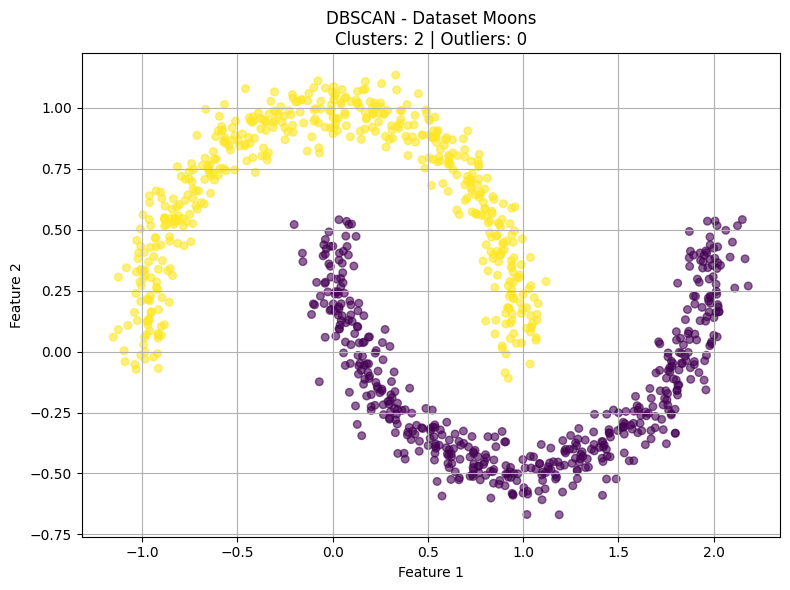

In [16]:
# ==========================================================
# DBSCAN - Dataset Moons
# ==========================================================

# Ajustar DBSCAN — este dataset requiere eps pequeño para captar la forma
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
y_pred_moons = dbscan_moons.fit_predict(X)

n_clusters = len(set(y_pred_moons)) - (1 if -1 in y_pred_moons else 0)
n_noise = list(y_pred_moons).count(-1)

print(f"DBSCAN - Moons: {n_clusters} clusters detectados, {n_noise} outliers")

# Visualización
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y_pred_moons, cmap='viridis', s=30, alpha=0.6)
plt.title(f'DBSCAN - Dataset Moons\nClusters: {n_clusters} | Outliers: {n_noise}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/dbscan_moons.png', dpi=300)
plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

El proceso de **clustering `DBSCAN`** ha arrojado resultados perfectos para este conjunto de datos, logrando la **separación exacta** de los dos clusters con forma de luna y **no detectando puntos atípicos (*outliers*)**:

- **Cluster Amarillo**: Representa la Luna Superior completa.
- **Cluster Morado**: Representa la Luna Inferior completa.
- **Outliers Detectados (0)**: Se logró una identificación excelente al no etiquetar ningún punto como atípico.
  
Este resultado satisfactorio se debe a una combinación de la naturaleza del algoritmo `DBSCAN` y el ajuste preciso de sus parámetros:

1. **Captura de conectividad**: A diferencia de algoritmos como K-Means, DBSCAN no asume que los clusters son esféricos o convexos. Su capacidad para identificar regiones de alta densidad conectadas le permite:
   - Seguir estructuras curvas y alargadas (como las lunas).
   - Ignorar la forma geométrica y centrarse solo en la densidad.
2. **Parámetros ajustados correctamente**: El éxito se debe a que los parámetros $\epsilon$ (eps) y $\text{min\_samples}$ fueron establecidos para reflejar la densidad y separación del dataset:
   - $\epsilon$ (eps) = 0.2: Este valor es lo suficientemente pequeño como para no conectar las dos lunas (que están separadas por aproximadamente 0.5 unidades). A la vez, es lo suficientemente grande como para conectar los puntos DENTRO de cada luna (donde la distancia típica entre vecinos es de 0.1 a 0.15).
   - $\text{min\_samples} = 5$: Este valor es adecuado para la densidad de las lunas, lo que ayuda a filtrar el ruido sin fragmentar los clusters principales.
3. **Caso ideal para DBSCAN**: El dataset de las lunas representa el caso de uso ideal para DBSCAN porque:
   - Tienen una **densidad uniforme**.
   - Están **bien separadas** en el espacio (un hueco claro entre ellas).
   - Cada luna es inherentemente una **región densa y conectada**.

In [17]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de DBSCAN jugando con los parámetros <i>eps</i> y <i>min_samples</i> para encontrar los grupos (y <i>outliers</i>) del dataset Circles.
</div>

DBSCAN - Circles: 2 clusters detectados, 0 outliers


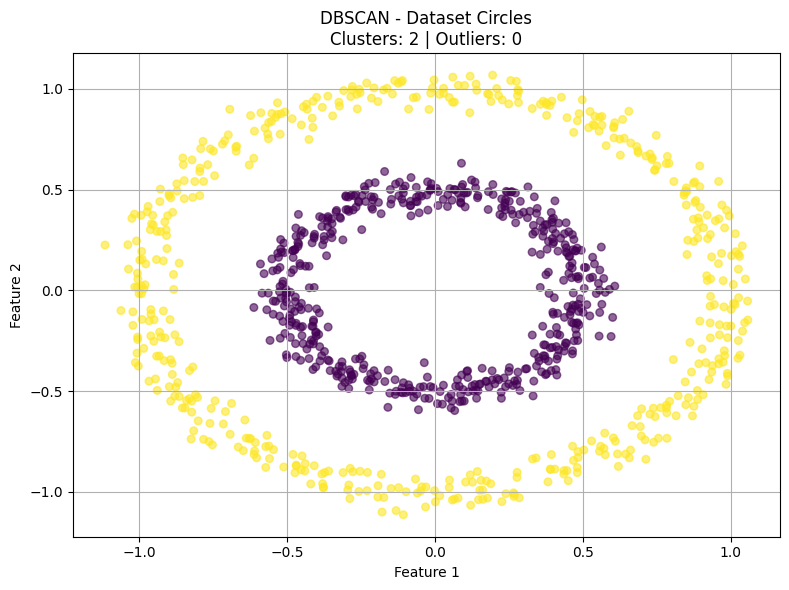

In [18]:
# ==========================================================
# DBSCAN - Dataset Circles
# ==========================================================

# Ajustar DBSCAN — requiere eps moderado
dbscan_circles = DBSCAN(eps=0.2, min_samples=5)
y_pred_circles = dbscan_circles.fit_predict(X)

n_clusters = len(set(y_pred_circles)) - (1 if -1 in y_pred_circles else 0)
n_noise = list(y_pred_circles).count(-1)

print(f"DBSCAN - Circles: {n_clusters} clusters detectados, {n_noise} outliers")

# Visualización
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y_pred_circles, cmap='viridis', s=30, alpha=0.6)
plt.title(f'DBSCAN - Dataset Circles\nClusters: {n_clusters} | Outliers: {n_noise}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/dbscan_circles.png', dpi=300)
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> ¿Qué ha sucedido? Explica los motivos por los que crees que se ha producido ese resultado.  
</div>

El proceso de **clustering `DBSCAN`** ha evidencia **resultados muy buenos** para este conjunto de datos, logrando una **separación perfecta** de los dos clusters concéntricos (círculo interior y anillo exterior) y **no detectando puntos atípicos (*outliers*)**:
- **Cluster Amarillo**: Representa el Círculo Exterior (Anillo) completo.
- **Cluster Morado**: Representa el Círculo Interior completo.
- **Outliers Detectados (0)**: Se obtuvo una identificación ideal al no etiquetar ningún punto como atípico.

El éxito de este resultado se debe a la ventaja de `DBSCAN` para manejar estructuras no convexas o anidadas, sumada a un ajuste de parámetros muy preciso:

1. **Estructuras Anidadas**: `DBSCAN` sobresale en este tipo de dataset porque:No utiliza centroides ni distancias a puntos centrales, que son la debilidad de K-Means en estructuras concéntricas.Solo considera la conectividad y densidad local.El círculo interior y el anillo exterior son, para DBSCAN, simplemente dos regiones densas espacialmente separadas.
2. **Parámetros Óptimos**: El éxito se debe a que los parámetros $\epsilon$ (eps) y $\text{min\_samples}$ fueron establecidos para reflejar la densidad y separación del dataset:
   - El parámetro $\epsilon$ (eps) de 0.2 fue crucial para garantizar que la brecha entre el anillo y el círculo interior no se "conectara". Este valor es menor que la distancia de separación entre los dos clusters (que es aproximadamente 0.3-0.4 unidades). Esto asegura que los **puntos del círculo interior NO puedan alcanzar el anillo**, evitando la fusión de los grupos. Simultáneamente, 0.2 es lo suficientemente grande para que los puntos **DENTRO** de cada estructura (con distancias típicas de vecinos de 0.1-0.15) se consideren densamente conectados, permitiendo la formación de los clusters.
   - $\text{min\_samples} = 5$: Este valor garantiza que solo las regiones con suficiente densidad (es decir, el círculo y el anillo) sean consideradas clusters válidos.

### 1 c. Algoritmos jerárquicos

En este apartado se pide visualizar mediante un [dendrograma](https://en.wikipedia.org/wiki/Dendrogram) la construcción progresiva de los grupos mediante un algoritmo jerárquico aglomerativo (estrategia *bottom-up*). Con ello se pretende encontrar un método gráfico para entender el comportamiento del algoritmo y encontrar los *clusters* deseados en cada dataset.

In [19]:
X, y = X_blobs, y_blobs

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Blobs.<br>
Puedes importar las librerías necesarias para ello.
</div>

In [20]:
import os

# Crear carpeta de salida
output_dir = r"../Visualizaciones/"
os.makedirs(output_dir, exist_ok=True) # Ejecutar solo si no se ha creado ya

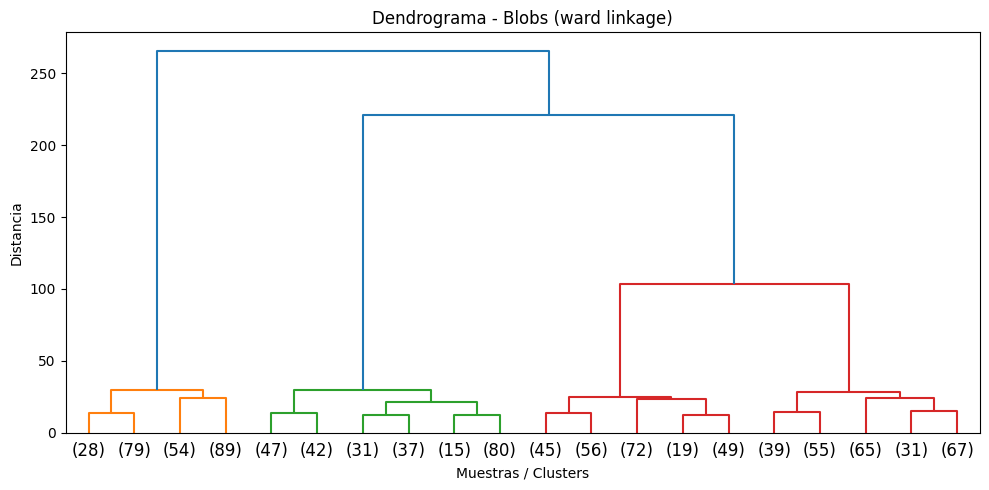

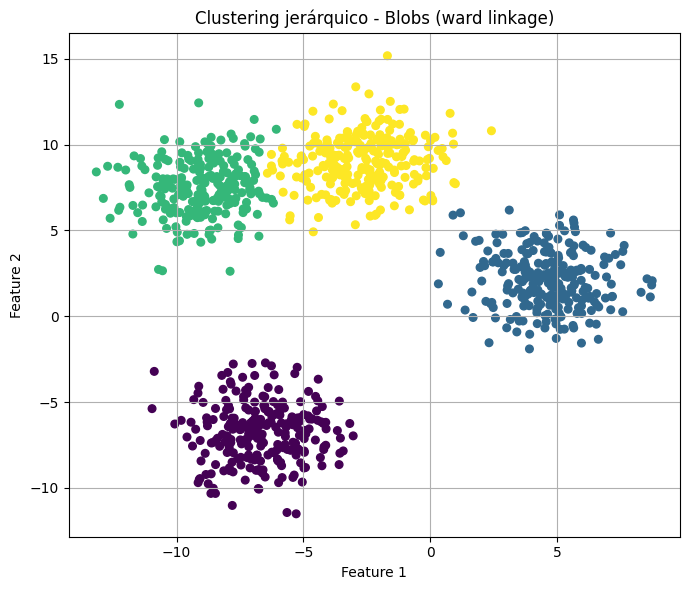

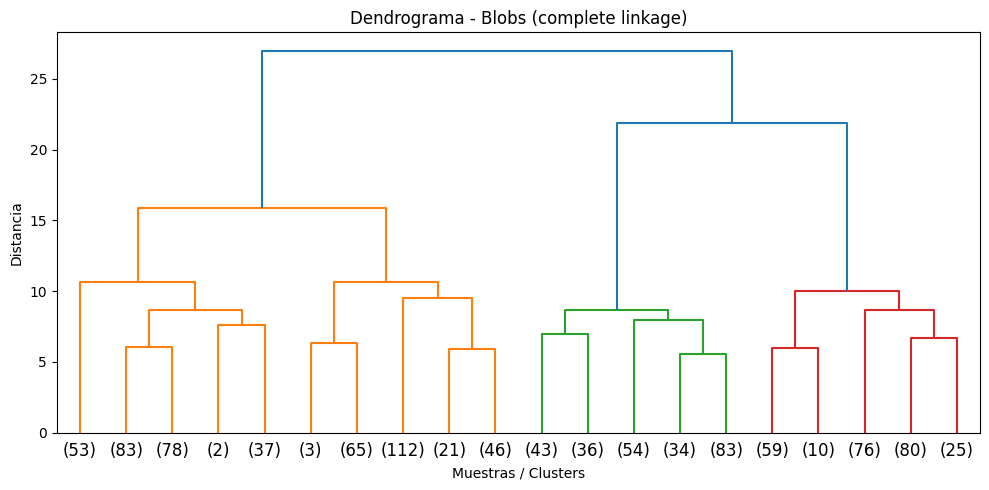

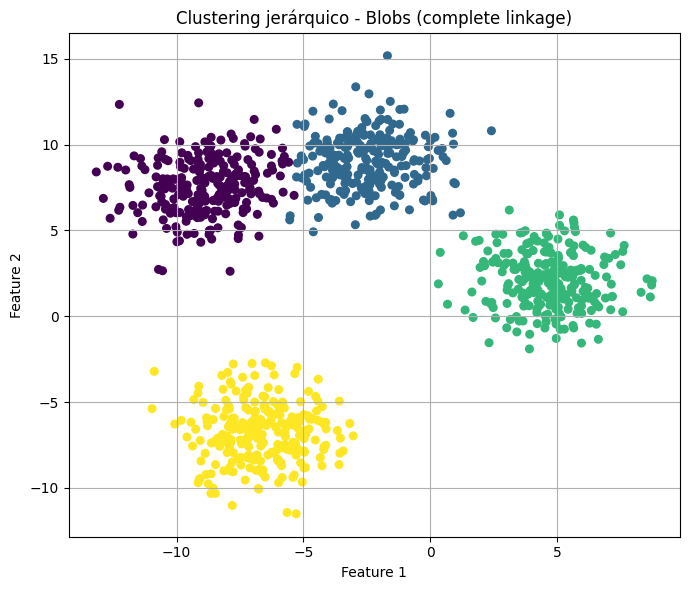

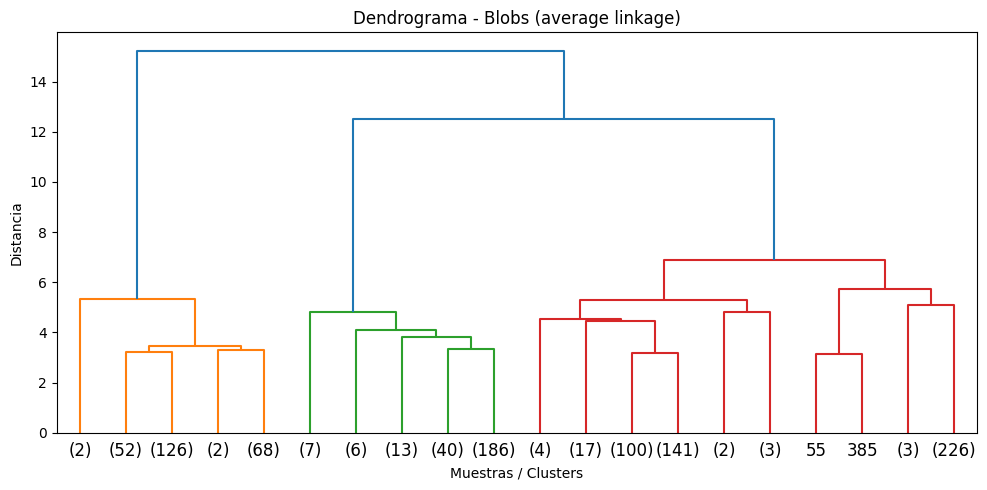

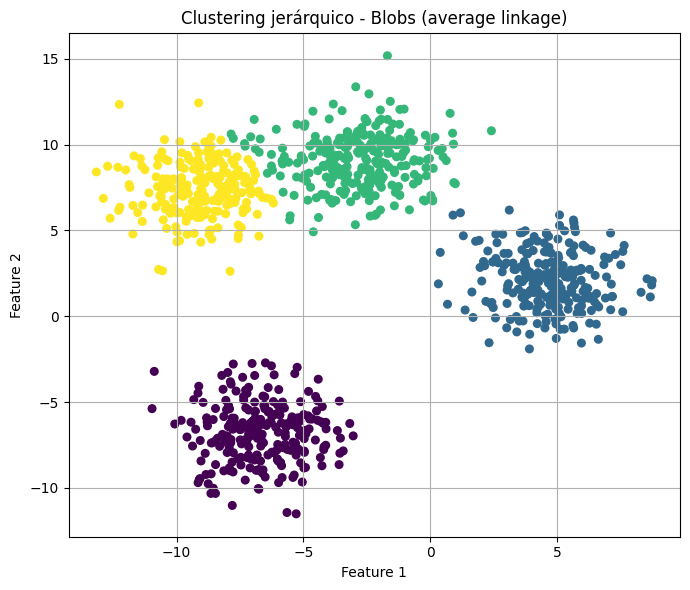

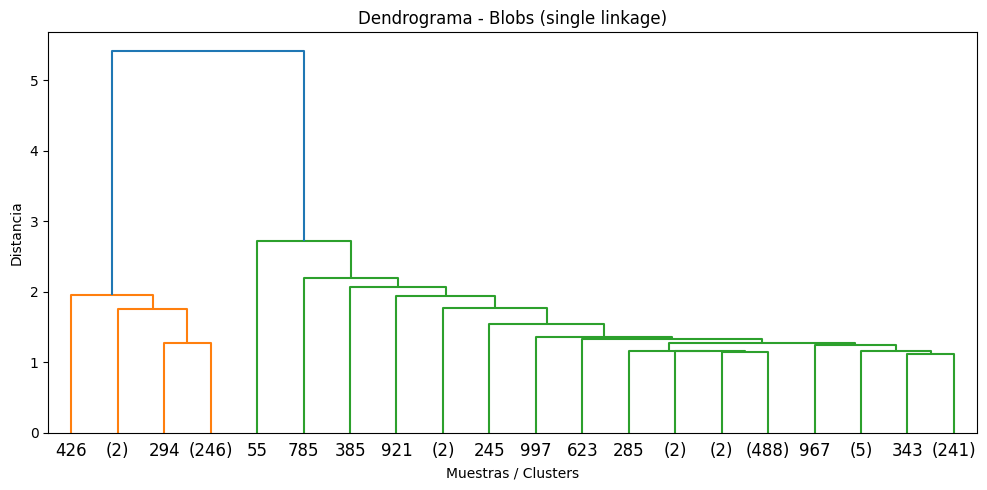

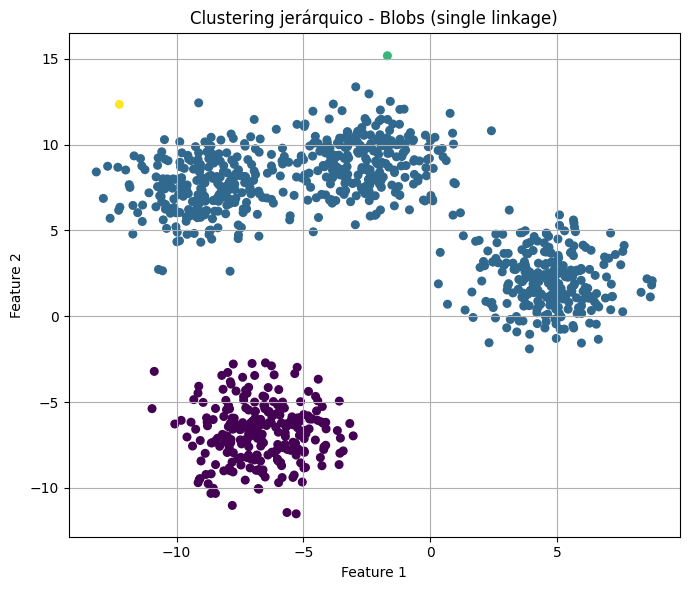

In [21]:
# ==========================================================
# Clustering jerárquico - Dataset Blobs
# ==========================================================

# Distinctos enlaces ("linkage") probados: 'ward', 'complete', 'average', 'single'
linkages = ['ward', 'complete', 'average', 'single']

for method in linkages:
    Z = linkage(X, method=method)

    # Dendrograma
    plt.figure(figsize=(10, 5))
    dendrogram(Z, truncate_mode='lastp', p=20)
    plt.title(f"Dendrograma - Blobs ({method} linkage)")
    plt.xlabel("Muestras / Clusters")
    plt.ylabel("Distancia")
    plt.tight_layout()
    ruta_dendo = os.path.join(output_dir, f"dendrograma_blobs_{method}.png")
    plt.savefig(ruta_dendo, dpi=300)
    plt.show()

    # Cortar el dendrograma para obtener clusters
    y_pred = fcluster(Z, t=4, criterion='maxclust')

    # Visualización de clusters resultantes
    plt.figure(figsize=(7,6))
    plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30)
    plt.title(f"Clustering jerárquico - Blobs ({method} linkage)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.tight_layout()

    ruta_clusters = os.path.join(output_dir, f"clusters_blobs_{method}.png")
    plt.savefig(ruta_clusters, dpi=300)
    plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

El análisis de los distintos **criterios de enlace (*linkage*)** muestra diferencias claras tanto en la estructura de los dendrogramas como en la calidad de los clusters obtenidos.

- **Average Linkage:**
  - El dendrograma obtenido con *average linkage* muestra una estructura clara y equilibrada, con cuatro ramas principales bien diferenciadas (colores naranja, verde, rojo y azul en los niveles bajos). Las fusiones iniciales se producen a distancias relativamente pequeñas, entre 3 y 5, mientras que la unión de los cuatro grupos principales ocurre a distancias mucho mayores, en torno a 12–15.
Este salto o “gap” entre niveles indica una separación natural en cuatro grupos bien definidos.

- **Complete Linkage:**
  - El dendrograma de *complete linkage* presenta una estructura algo más desbalanceada que la del método anterior. Se observan dos ramas principales que se fusionan a una distancia muy alta (alrededor de 26), y dentro de cada una hay subdivisiones que ocurren a distancias medias (entre 8 y 15).
  Las fusiones finales muestran una mayor dispersión en las alturas del dendrograma, reflejando cierta asimetría en la estructura jerárquica.

- **Single Linkage**

  - En este caso, el dendrograma revela un problema claro: una estructura extremadamente desbalanceada provocada por el conocido *[efecto cadena](https://openaccess.uoc.edu/server/api/core/bitstreams/6a121978-e877-4f5d-a76c-b6ff0138f8d1/content)* (*chaining*). La primera gran fusión ocurre a distancia muy baja (~2), y a partir de ahí aparece una rama azul dominante que crece progresivamente a medida que se van uniendo los puntos. No existe una separación clara en cuatro niveles distintos, y el dendrograma pierde legibilidad.

-  **Ward Linkage**
   - El dendrograma de *Ward linkage* es el más equilibrado y fácil de interpretar. Se observan cuatro ramas principales claramente separadas, con fusiones iniciales a distancias pequeñas (20–30) y un salto muy pronunciado antes de la fusión de los grupos principales, que se produce entre 100 y 250.
   Este gran salto facilita enormemente la identificación del punto de corte óptimo en el dendrograma.

Por lo tanto, **el método que mejor se comporta en este dataset es Ward linkage**. Su dendrograma es el más interpretable, con un salto muy claro entre fusiones internas y externas (20–30 frente a 100–250), lo que permite determinar fácilmente el número óptimo de clusters. Además, este criterio es coherente con la geometría de los datos: los *blobs* son aproximadamente esféricos y están bien separados, justo el tipo de estructura que *Ward* busca al minimizar la varianza interna.

In [22]:
X, y = X_moons, y_moons

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Moons.<br>
Puedes importar las librerías necesarias para ello.
</div>

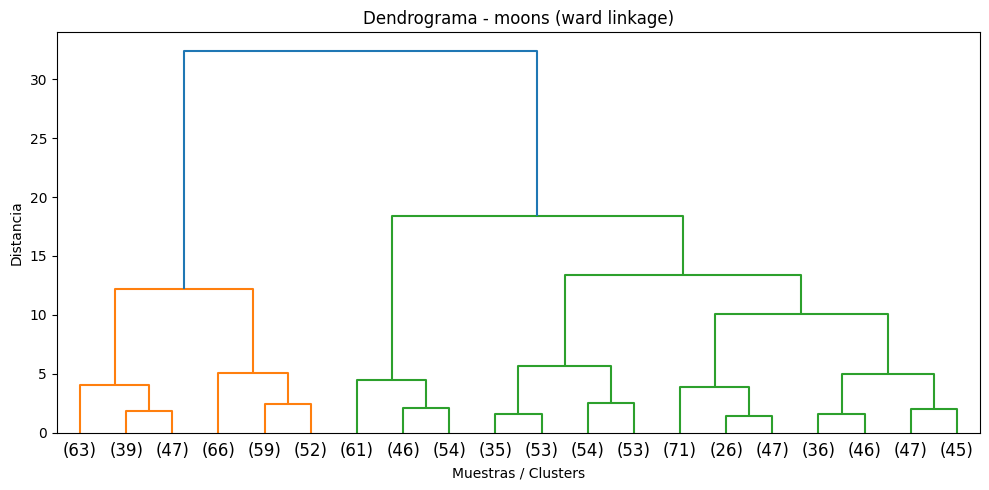

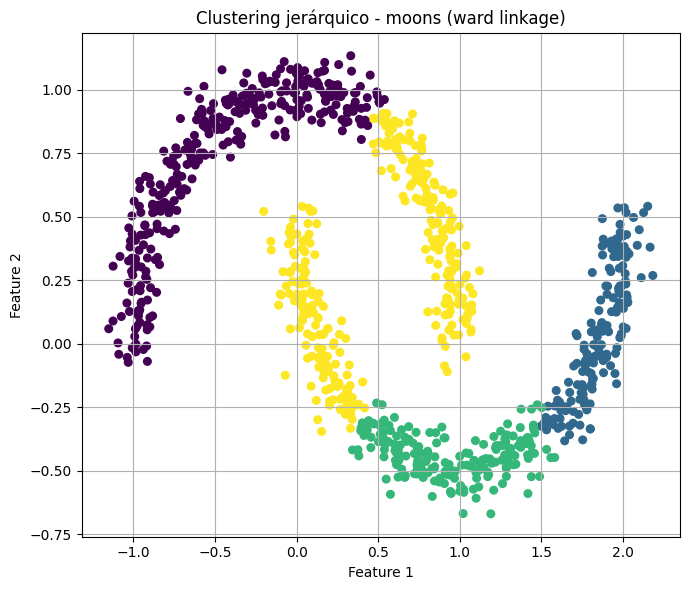

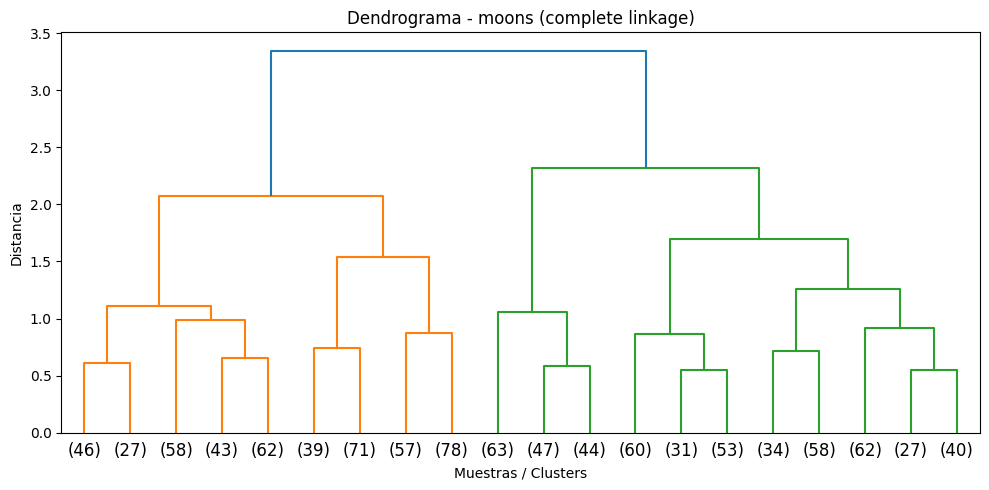

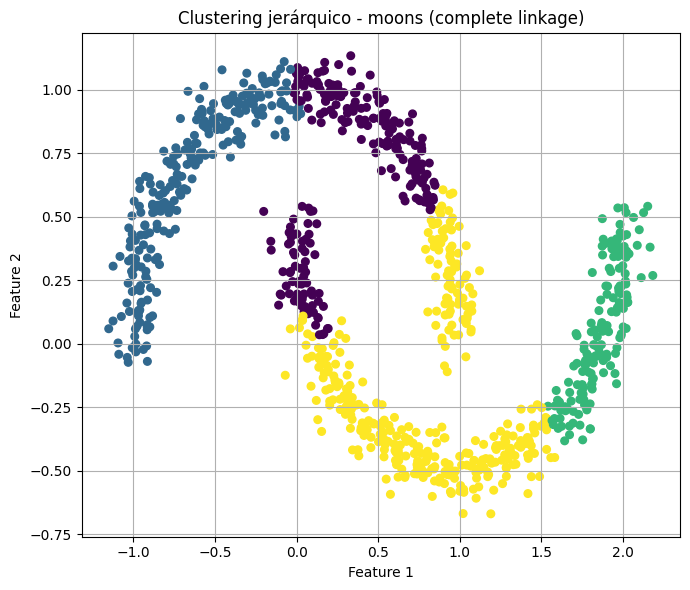

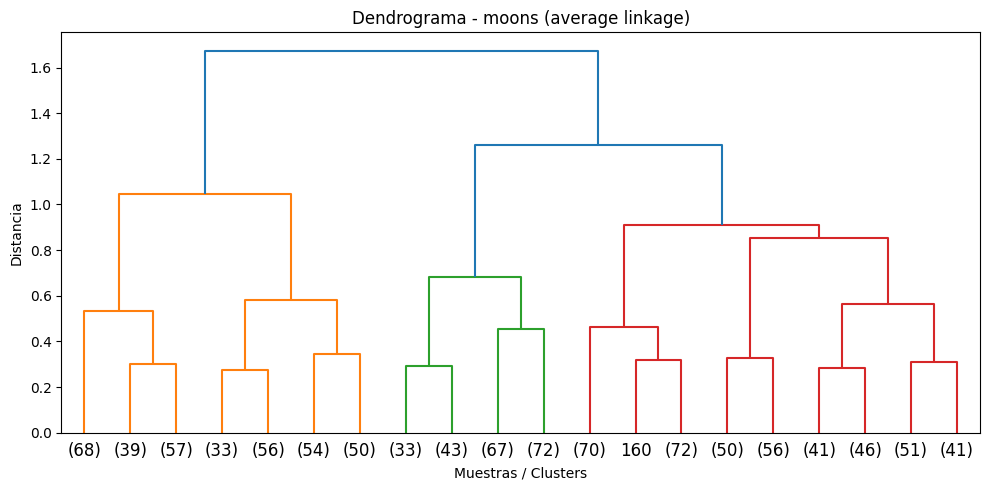

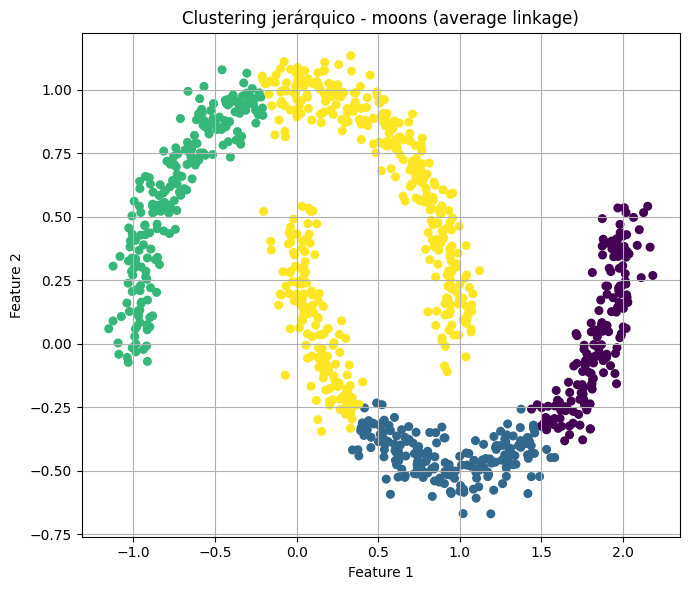

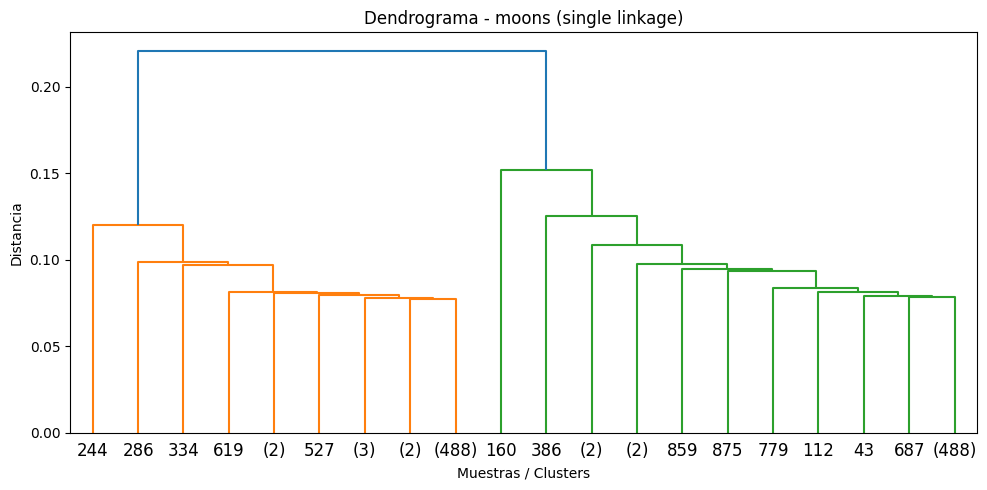

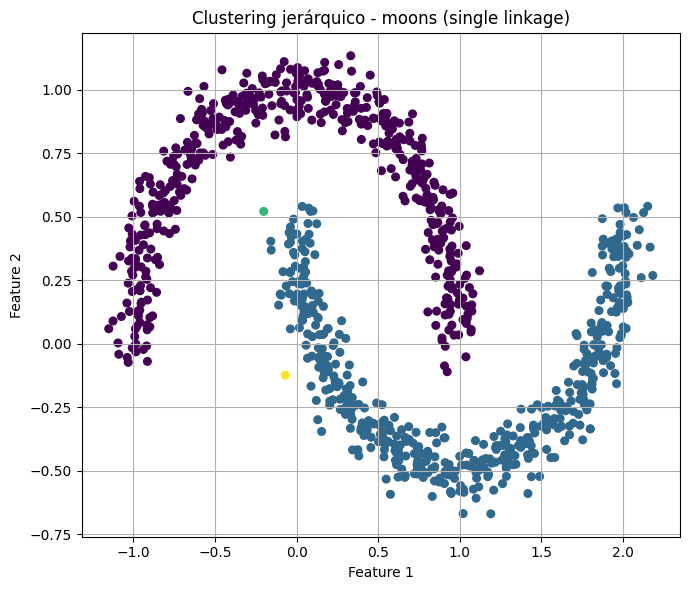

In [23]:
# ==========================================================
# Clustering jerárquico - Dataset moons
# ==========================================================

# Distinctos enlaces ("linkage") probados: 'ward', 'complete', 'average', 'single'
linkages = ['ward', 'complete', 'average', 'single']

for method in linkages:
    Z = linkage(X, method=method)

    # Dendrograma
    plt.figure(figsize=(10, 5))
    dendrogram(Z, truncate_mode='lastp', p=20)
    plt.title(f"Dendrograma - moons ({method} linkage)")
    plt.xlabel("Muestras / Clusters")
    plt.ylabel("Distancia")
    plt.tight_layout()
    ruta_dendo = os.path.join(output_dir, f"dendrograma_moons_{method}.png")
    plt.savefig(ruta_dendo, dpi=300)
    plt.show()

    # Cortar el dendrograma para obtener clusters
    y_pred = fcluster(Z, t=4, criterion='maxclust')

    # Visualización de clusters resultantes
    plt.figure(figsize=(7,6))
    plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=30)
    plt.title(f"Clustering jerárquico - moons ({method} linkage)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.tight_layout()
    ruta_clusters = os.path.join(output_dir, f"clusters_moons_{method}.png")
    plt.savefig(ruta_clusters, dpi=300)
    plt.show()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

Al aplicar los distintos criterios de enlace sobre el dataset *Moons*, los resultados muestran comportamientos muy contrastados según la forma de las lunas y la manera en que cada algoritmo calcula las distancias entre clusters.

- **Average Linkage:** 
  - El dendrograma muestra una estructura relativamente equilibrada, con fusiones progresivas desde distancias bajas hasta un salto final moderado. Aun así, el clustering **no logra reflejar correctamente la estructura en forma de lunas**, ya que las divisiones tienden a ser verticales o diagonales, dando lugar a varios grupos pequeños en lugar de las dos medias lunas esperadas. Esto ocurre porque el método **promedia las distancias** entre todos los puntos de los clusters, y en este dataset las lunas están separadas más claramente en dirección horizontal. El algoritmo, al centrarse en distancias promedio, prefiere dividir verticalmente, donde las separaciones medias son mayores, antes que seguir las curvas naturales.

- **Complete Linkage:** 
  - El dendrograma se vuelve más desbalanceado y las fusiones finales ocurren a distancias mucho más altas. Este método es especialmente sensible a la elongación de los grupos ([es sensible a los valores outliers](https://openaccess.uoc.edu/server/api/core/bitstreams/6a121978-e877-4f5d-a76c-b6ff0138f8d1/content)), ya que **se basa en la distancia máxima entre puntos**. Al intentar minimizar el diámetro de los clusters, tiende a cortar el espacio en franjas verticales que atraviesan ambas lunas, produciendo resultados completamente incorrectos. En lugar de identificar las dos formas curvas, el algoritmo crea divisiones artificiales que reducen el tamaño máximo de cada grupo, sacrificando la coherencia estructural.

- **Single Linkage** 
  - Por el contrario *single linkage* muestra un dendrograma extremadamente desbalanceado (efecto *chaining*), pero esta vez ese problema se convierte en una ventaja. Aunque la estructura parece caótica, el clustering resultante es casi perfecto, observando como cada luna queda representada como una cadena continua de puntos conectados. Esto es debido a que se fusionan grupos si existe al menos un par de puntos cercanos, lo que encaja de forma ideal con las lunas, ya que dentro de cada una hay una densa red de vecinos próximos, mientras que entre ellas existe un pequeño pero claro hueco. Así, el algoritmo sigue la conectividad de las curvas y logra una separación natural, con solo unos pocos puntos ambiguos.

- **Ward Linkage:** 
  - Ofrece un resultado algo mejor que *Complete*, pero sigue siendo **inadecuado para este tipo de estructura**. Su dendrograma presenta una gran rama dominante y un salto final muy alto, lo que refleja fusiones tardías y poco coherentes. Al **minimizar la varianza dentro de cada grupo**, *Ward* favorece clusters compactos y aproximadamente esféricos, una suposición que las lunas violan completamente. De modo que como las formas son cóncavas, los centroides caen fuera de las lunas, lo que confunde la asignación de puntos y provoca cortes diagonales que dividen los arcos naturales en segmentos artificiales.

Por lo tanto, el método que mejor se adapta al dataset *Moons* es claramente **Single Linkage**. Su sensibilidad a la conectividad local le permite seguir las formas curvadas sin imponer una estructura convexa ni depender de medidas globales de distancia. Volver a resaltar que, lo que en otros contextos sería una debilidad (la tendencia a encadenar puntos sucesivos) aquí se convierte en la clave para detectar las lunas con precisión. En cambio, *Complete* y *Ward* fallan al intentar imponer geometrías compactas, mientras que *Average* se queda en un punto intermedio..

In [24]:
X, y = X_circles, y_circles

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Prueba la implementación de <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">clustering jerárquico de scipy</a> probando distintos <a href="https://en.wikipedia.org/wiki/Hierarchical_clustering#Linkage_criteria">criterios de enlace o <i>linkage</i></a> permitiendo identificar los clusters subyacentes (mostrando su resultado) y su dendrograma para el dataset Circles.<br>
Puedes importar las librerías necesarias para ello.
</div>

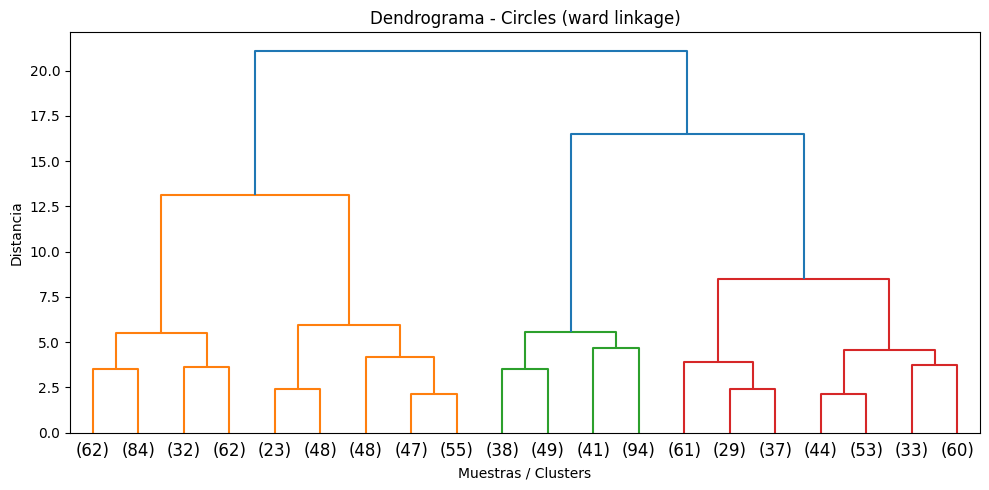

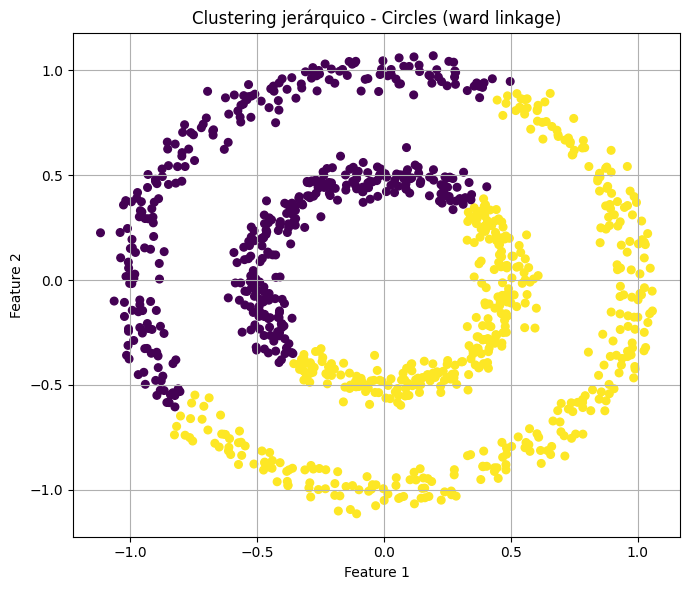

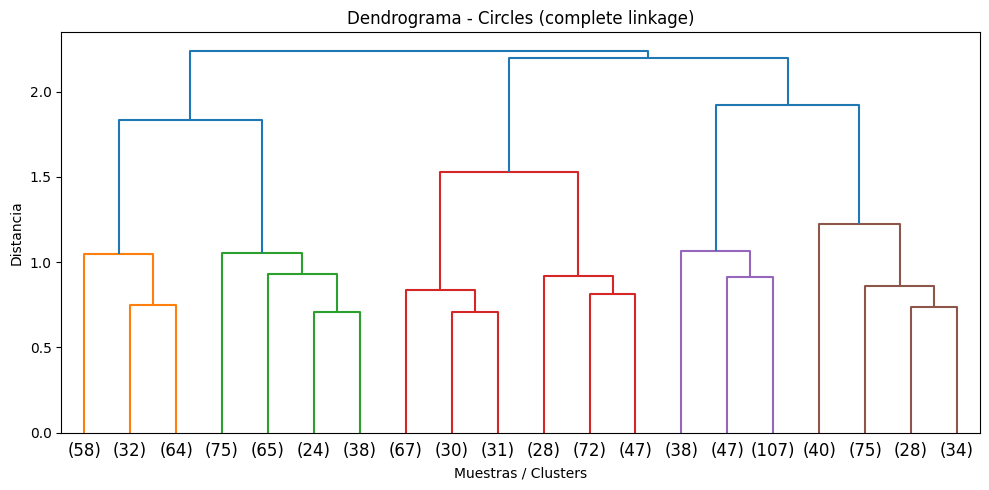

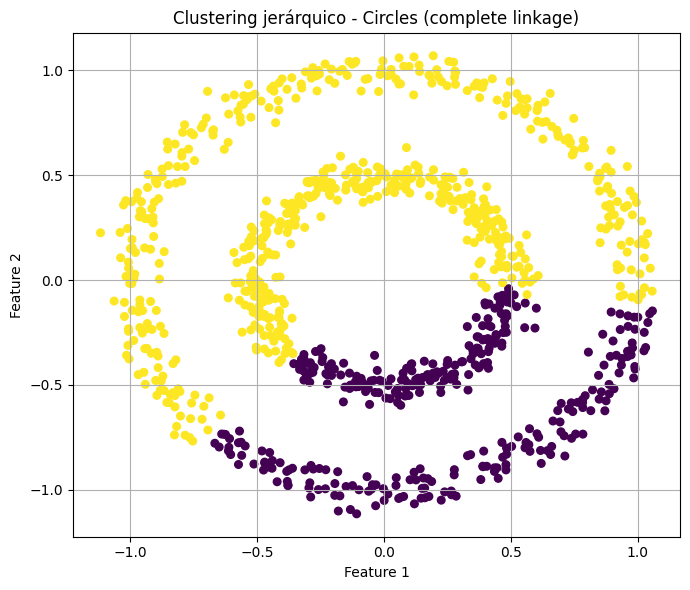

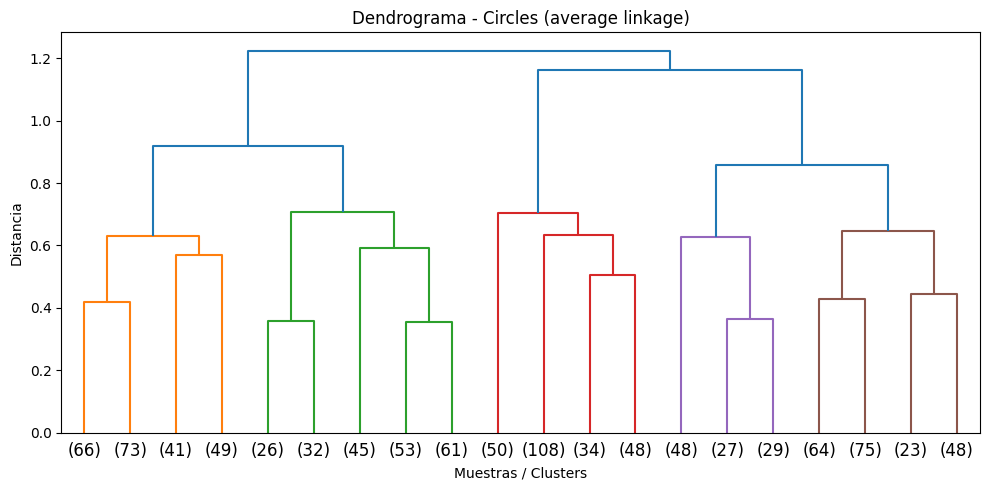

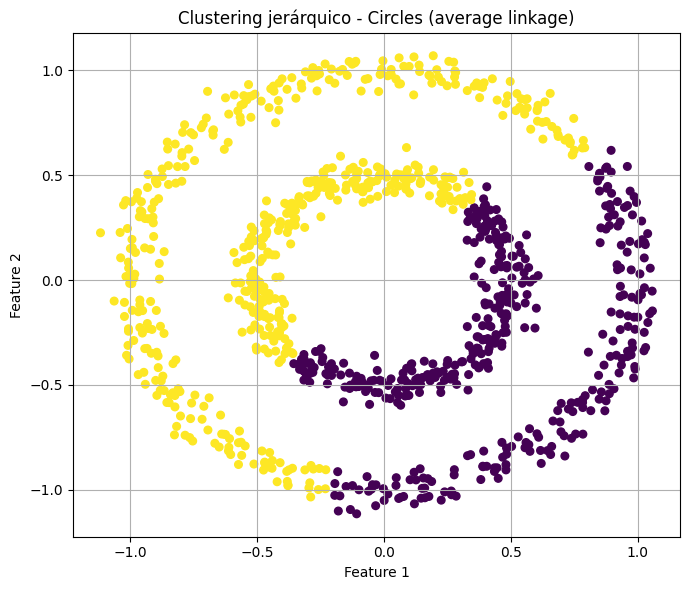

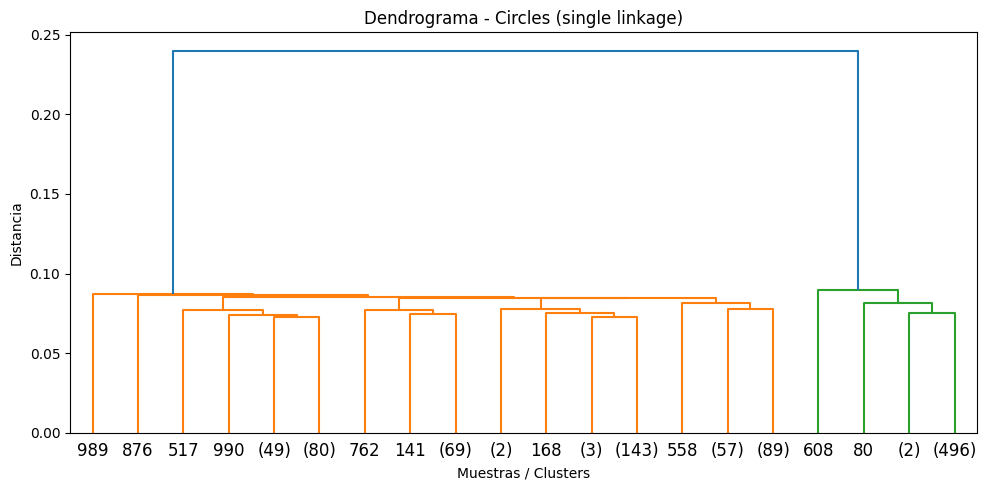

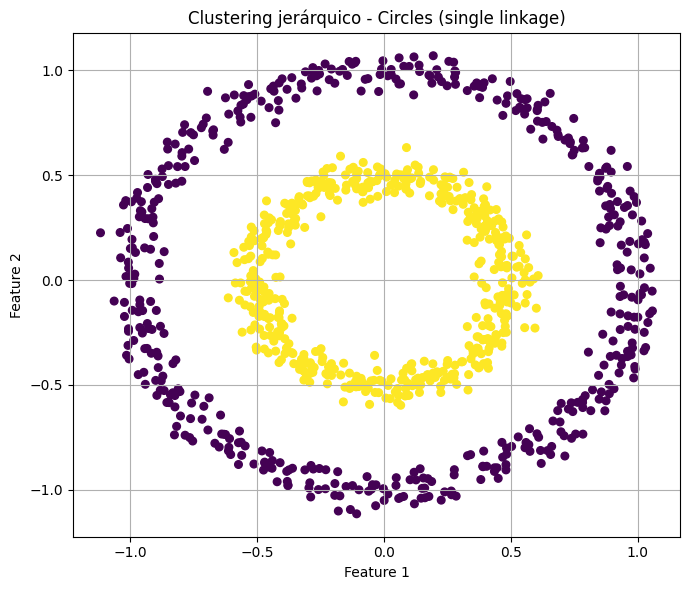

In [25]:
# ==========================================================
# Clustering jerárquico - Dataset Circles
# ==========================================================

linkages = ['ward', 'complete', 'average', 'single']

for method in linkages:
    Z = linkage(X, method=method)

    plt.figure(figsize=(10, 5))
    dendrogram(Z, truncate_mode='lastp', p=20)
    plt.title(f"Dendrograma - Circles ({method} linkage)")
    plt.xlabel("Muestras / Clusters")
    plt.ylabel("Distancia")
    plt.tight_layout()

    ruta_dendo = os.path.join(output_dir, f"dendrograma_circles_{method}.png")
    plt.savefig(ruta_dendo, dpi=300)
    plt.show()

    # Intentamos cortar en 2 clusters (círculo interior/exterior)
    y_pred = fcluster(Z, t=2, criterion='maxclust')

    plt.figure(figsize=(7,6))
    plt.scatter(X[:,0], X[:,1], c=y_pred, cmap='viridis', s=30)
    plt.title(f"Clustering jerárquico - Circles ({method} linkage)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.tight_layout()

    ruta_clusters = os.path.join(output_dir, f"clusters_circles_{method}.png")
    plt.savefig(ruta_clusters, dpi=300)
    plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Interpreta el dendrograma y comenta qué criterio de enlace se ha comportado mejor. ¿Por qué?
</div>

Al aplicar distintos criterios de enlace al dataset *Circles*, los resultados muestran comportamientos muy distintos según la geometría del método y la estructura de los datos.

- **Average Linkage**
  - El dendrograma presenta una estructura compleja y sin saltos claros, pero el clustering con *$k$ = 2* logra separar correctamente el círculo interior y el anillo exterior. Aunque hay algunas asignaciones ambiguas, el método funciona razonablemente bien gracias a que **capta la distancia promedio entre los puntos de cada grupo**, suficiente para distinguir el pequeño hueco que los separa.

- **Complete Linkage**:
  - Produce resultados similares, pero con una separación más limpia y fronteras mejor definidas. Su dendrograma muestra una estructura más equilibrada y un hueco o *gap* moderado entre niveles, lo que refleja que preserva mejor la distancia entre las dos regiones. Al **usar la distancia máxima entre puntos**, evita que se formen “puentes” entre el círculo y el anillo.

- **Single Linkage**:
  - Al contrario, *single linkage* genera un dendrograma muy desbalanceado debido al efecto *chaining*, pero ofrece la mejor clasificación posible, al separar los dos círculos de forma perfecta y sin errores. Aunque el dendrograma parece caótico, **este método detecta conectividad más que compacidad**, lo que encaja perfectamente con la forma circular y continua del dataset. El anillo y el círculo se forman como dos cadenas bien separadas, sin puntos que conecten ambas estructuras.

- **Ward Linkage** 
  - Es el que se comporta peor. Tiende a fusionar grupos prematuramente y produce divisiones incorrectas que cortan el anillo de forma diagonal. Esto ocurre porque ***Ward* minimiza la varianza interna y asume clusters compactos y convexos**, una suposición que el dataset *Circles* no cumple. El anillo, al tener un hueco central, rompe esas condiciones y confunde al algoritmo.

Por lo tanto, el resultado más destacable es que **Single Linkage** se adapta sorprendentemente bien a la geometría circular, mientras que los demás métodos funcionan correctamente pero con limitaciones, y **Ward** falla por completo debido a la forma no convexa de los datos.

## 2. *Clustering* y reducción de dimensionalidad culinaria: (6 puntos)

En este ejercicio exploraremos cómo mediante clustering podemos descubrir patrones ocultos en miles de recetas reales de Food.com. Partiremos de un conjunto de unas 30.000 recetas con su nombre, descripción e ingredientes, y nuestro objetivo será agruparlas por similitud para ver qué tipos de platos emergen sin supervisión: ¿se juntan los postres? ¿los platos con ajo? ¿las recetas mediterráneas?

Probaremos distintas formas de representar las recetas: desde una codificación one-hot basada en los ingredientes, hasta embeddings semánticos generados con modelos de lenguaje (como MiniLM). Con ello veremos cómo cambia la estructura de los datos según el tipo de representación y qué tipo de similitud capturan mejor.

Finalmente aplicaremos técnicas de reducción de dimensionalidad con UMAP y varios métodos de clustering que podrás probar (KMeans, DBSCAN, HDBSCAN, Mean-shift, jerárquico...) para visualizar y analizar los grupos resultantes. Terminaremos interpretando los clusters más grandes a través de sus ingredientes y recetas representativas, comparando qué enfoque refleja mejor la *lógica culinaria* del conjunto.

In [26]:
### FUNCIONES AUXILIARES ###

def describe_df(data):
    """
    Proporciona un resumen del DataFrame, incluyendo forma, tipos de datos, estadísticas básicas,
    conteo de valores nulos, valores únicos, mediana y rango de fechas para columnas tipo datetime.

    :param data: DataFrame de pandas.
    :return: DataFrame con el resumen del DataFrame dado.
    """
    # Crear base del resumen
    total = len(data)
    summary = pd.DataFrame({
        'Column': data.columns,
        'Data Type': data.dtypes.astype(str),
        'Non-null Count': data.count().values,
        '% Null Values': ((data.isnull().sum() / total) * 100).round(2).values,
        'Unique Values': data.nunique().values
    })

    summary['Shape'] = f"{data.shape[0]} rows, {data.shape[1]} columns"

    # Estadísticas para columnas numéricas
    numeric_cols = data.select_dtypes(include=['number']).columns
    if not numeric_cols.empty:
        describe_stats = data[numeric_cols].describe().T
        describe_stats = describe_stats.rename(columns={'50%': 'median'})[
            ['mean', 'median', 'std', 'min', '25%',  '75%', 'max']
        ]
        describe_stats.reset_index(inplace=True)
        describe_stats.rename(columns={'index': 'Column'}, inplace=True)

        summary = pd.merge(summary, describe_stats, on='Column', how='left')

    # Rango de fechas para columnas datetime
    datetime_cols = data.select_dtypes(include=['datetime', 'datetime64[ns]']).columns
    if not datetime_cols.empty:
        date_ranges = pd.DataFrame({
            'Column': datetime_cols,
            'Min Date': data[datetime_cols].min().values,
            'Max Date': data[datetime_cols].max().values
        })
        summary = pd.merge(summary, date_ranges, on='Column', how='left')

    return summary

def detect_duplicates(df):
    """
    Detecta duplicados en un DataFrame y devuelve un nuevo DataFrame con los duplicados.

    :param df: DataFrame de pandas.
    :return: DataFrame con los duplicados detectados.
    """
    try:
        return df[df.duplicated(keep=False)]
    except Exception as e:
        print("Error detectando duplicados:", e)
        return None

def unique_df(df):
    """
    Imprime un resumen de las categorías únicas para las variables categóricas de un DataFrame.

    :param df: DataFrame de pandas.
    """
    categorical_columns = df.select_dtypes(include=['category', 'object']).columns

    if len(categorical_columns) == 0:
        print("No se encontraron columnas categóricas u objeto en el DataFrame.")
        return

    for column in categorical_columns:
        print(f"Resumen para la columna '{column}':\n{df[column].unique()}\n")


In [27]:
# Carga del dataset de recetas
df = pd.read_csv(r'../Data/recipes.csv')

# Visualización de las primeras filas
df.head(3)

,id,name,description,ingredients,ingredients_raw_str,serving_size,servings,steps,tags,search_terms
0,56594,Sun-Dried Tomato Palmiers,"from ""INVITATION TO DINNER"" cookbook","['garlic cloves', 'pesto sauce', 'frozen puff ...","[""2 garlic cloves, peeled and finely min...",1 (675 g),1,"['Preheat the oven to 350 degrees F.', 'Stir t...","['60-minutes-or-less', 'time-to-make', 'course...",{'appetizer'}
1,311362,Char Siu Pork Corn and Bok Choy Stir Fry,Here is another wok recipe I like stir fry's a...,"['peanut oil', 'pork fillets', 'garlic cloves'...","[""2 tablespoons peanut oil"",""600 g p...",1 (364 g),4,['Heat 1 tabelspoon of oil in a wok and cook p...,"['60-minutes-or-less', 'time-to-make', 'course...","{'pork', 'dinner'}"
2,248335,Black Cat Fudge,These adorable fudge peices will be a huge hit...,"['semisweet chocolate', 'butter', 'light corn ...","[""8 ounces semisweet chocolate, coarsely ...",1 (42 g),24,"['Line 11x7 inches pan with foil, extending fo...","['time-to-make', 'course', 'preparation', 'occ...",{'dessert'}


In [28]:
# Resumen del DataFrame
describe_df(df)

,Column,Data Type,Non-null Count,% Null Values,Unique Values,Shape,mean,median,std,min,25%,75%,max
0,id,int64,50000,0.00,50000,"50000 rows, 10 columns",270316.64732,269245.5,154109.531409,41.0,137629.75,403126.5,537804.0
1,name,object,50000,0.00,47154,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,description,object,49053,1.89,48245,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ingredients,object,50000,0.00,49939,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ingredients_raw_str,object,50000,0.00,49984,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,serving_size,object,50000,0.00,2605,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,servings,int64,50000,0.00,89,"50000 rows, 10 columns",6.68870,4.0,8.609285,1.0,4.00,8.0,390.0
7,steps,object,50000,0.00,49967,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,tags,object,50000,0.00,46201,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,search_terms,object,50000,0.00,11451,"50000 rows, 10 columns",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# Detección de duplicados
detect_duplicates(df)

,id,name,description,ingredients,ingredients_raw_str,serving_size,servings,steps,tags,search_terms


In [30]:
#  Resumen de las categorías únicas para variables categóricas
unique_df(df)

Resumen para la columna 'name':
['Sun-Dried Tomato Palmiers' 'Char Siu Pork Corn and Bok Choy Stir Fry'
 'Black Cat Fudge' ... 'Mexican Dip' 'Thai Basil Shrimp'
 'Roasted Eggplant and Tomato Pizza']

Resumen para la columna 'description':
['from "INVITATION TO DINNER" cookbook'
 "Here is another wok recipe I like stir fry's as they are quick, easy and reasonably priced to prepare and they are a great way to use up your left over vegetables in a nutritious meal. I served as is but it would go well with steamed rice, as I said yesterday we are watching our carb intake at the moment. This again would serve 3 good portions 4 smaller ones as is, or 4 good portions if served with rice.\r\n\r\nNote: Char Siu Sauce also know as chinese BBQ sauce. It is a paste like ingredient that is dark-red-brown in colour and has a sweet and spicy flavour. Made from fermented soy beans, honey and various spices."
 'These adorable fudge peices will be a huge hit with the kids.' ...
 'This is an original sala

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Crea una nueva columna en el <em>DataFrame</em> que contenga, en una sola cadena de texto,
    <strong>toda la información disponible de cada receta</strong>. Concatena, en ese orden:
  <ul>
    <li>Título (<code>name</code>)</li>
    <li>Descripción (<code>description</code>)</li>
    <li>Lista de ingredientes (<code>ingredients</code>)</li>
    <li>Pasos de preparación (<code>steps</code>)</li>
    <li>Etiquetas (<code>tags</code>) y, si existe, términos de búsqueda (<code>search_terms</code>)</li>
  </ul>
  <p>
    Esta columna representará una descripción textual completa de la receta y se usará en el siguiente paso
    para generar sus <strong>embeddings semánticos</strong>.
  </p>
  <p>
    Ten en cuenta:
  </p>
  <ul>
    <li>Convierte listas o conjuntos a texto legible (por ejemplo, separando por comas).</li>
    <li>Gestiona valores nulos para evitar errores de concatenación.</li>
    <li>Verifica que el texto resultante mantiene la información relevante y es coherente.</li>
  </ul>
</div>

### 2.1. Limpieza y normalizacion

Algunas columnas vienen con listas codificadas como texto ("['a','b']") o conjuntos ("{'x','y'}"). Esto significa que la lista está almacenada como texto, no como lista real de Python.

De modo que para evitar errores las convierto a texto legible, creando la funcion safe_to_text(). Posteriormente construyo la nueva columna con las columnas indicadas en el enunciado, completando los valores nulos (si los hubiera) con un espacio vacio.

In [31]:
import ast  # para convertir strings de listas a listas reales 

# =============================================================
# Limpieza y normalizacion
# =============================================================

def safe_to_text(x):
    """
    Convierte listas o conjuntos codificados como texto en una cadena legible.
    Gestiona valores nulos y errores de parseo.
    """
    if pd.isna(x):
        return ""
    if isinstance(x, str):
        try:
            val = ast.literal_eval(x)
            if isinstance(val, (list, set)):
                return ", ".join(map(str, val))
        except (ValueError, SyntaxError):
            pass
    return str(x)

# --- Construcción robusta de la columna unificada ---
sep = " | "  # Separador seguro que no aparece en el texto

df['text_full'] = (
    df['name'].fillna('') + sep +
    df['description'].fillna('') + sep +
    df['ingredients'].apply(safe_to_text) + sep +
    df['steps'].apply(safe_to_text) + sep +
    df['tags'].apply(safe_to_text) + sep +
    df['search_terms'].apply(safe_to_text)
)

# Aseguramos limpieza final (sin separadores repetidos, espacios extra, etc.)
df['text_full'] = (
    df['text_full']
      .str.replace(r'\s+', ' ', regex=True)
      .str.replace(r'(\|\s*){2,}', '| ', regex=True)  # evita duplicados de separador
      .str.strip('| ')
      .str.strip()
)

print(f"Primeros valores de 'text_full':\n{df['text_full'].unique()[:5]}")

Primeros valores de 'text_full':
['Sun-Dried Tomato Palmiers | from "INVITATION TO DINNER" cookbook | garlic cloves, pesto sauce, frozen puff pastry, fontina, parmigiano-reggiano cheese, sun-dried tomato, fresh ground black pepper | Preheat the oven to 350 degrees F., Stir the minced garlic into the prepared pesto., Unfold the pastry sheets and on a lightly floured board roll them slightly with a rolling pin to make a rectangle that measures 11 by 12 inches., Cut each pastry sheet in half lengthwise., Spread 1/4 of the pesto (2 tablespoons) over the entire surface of each pastry sheet., Divide and sprinkle the cheeses and sun-dried tomatoes over the pesto on each pastry sheet and season each with a pinch of pepper., Tightly roll each sheet, starting at a long side, into a 1-inch-wide log., Using a sharp serrated knife, cut each log into about twenty-four 1/2-inch slices and place then on ungreased baking sheets 1 1/2 inches apart., (The palmiers may be baked right away or refrigerated 

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Genera los <strong>embeddings semánticos</strong> de las recetas utilizando el modelo 
    <code>all-MiniLM-L6-v2</code> de la librería <code>sentence-transformers</code>.
    Este modelo es una versión ligera de BERT que transforma frases completas en vectores numéricos
    que capturan su significado.
  <p>
    Usa como entrada la columna con toda la información de la receta (título, descripción, ingredientes, pasos y etiquetas)
    para obtener una representación semántica de cada una.
  </p>
  <p>
    Incrementa el parámetro <code>batch_size</code> en <code>encode()</code> para aprovechar mejor los recursos 
    y activa <code>show_progress_bar=True</code> para visualizar el progreso durante la generación de embeddings.
  </p>
</div>

A continuación genero los [embeddings](https://openwebinars.net/blog/embeddings/) semánticos de las recetas usando el modelo [`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2) de `sentence-transformers`, tomando como entrada la columna `text_full` que unifique en la celda anterior para generar:
- `embeddings`: tipo array de numpy de forma (n_recetas, 384)   .
- `df[embeddings]`: Columna con cada vector para futuras búsquedas semánticas.

In [32]:
from sentence_transformers import SentenceTransformer

# =============================================================
# Carga del modelo de embeddings semánticos
# =============================================================

# all-MiniLM-L6-v2 es un modelo ligero y eficiente (384 dimensiones)
model = SentenceTransformer('all-MiniLM-L6-v2')

# --- Generación de embeddings a partir del texto unificado ---
# Uso batch_size alto para eficiencia y barra de progreso para seguimiento
embeddings = model.encode(
    df['text_full'].tolist(),
    batch_size=64,              
    show_progress_bar=True,
    convert_to_numpy=True
)

# --- Almacenamos los embeddings como columna separada o matriz ---
df['embedding'] = list(embeddings)

# Verificamos tamaño y forma
print(f"Embeddings generados: {embeddings.shape}")
print(df[['name', 'embedding']].head(3))

Batches:   0%|          | 0/782 [00:00<?, ?it/s]

Embeddings generados: (50000, 384)
                                       name  \
0                 Sun-Dried Tomato Palmiers   
1  Char Siu Pork Corn and Bok Choy Stir Fry   
2                           Black Cat Fudge   

                                           embedding  
0  [-0.087734625, 0.0032690035, -0.057603437, 0.0...  
1  [-0.11362725, -0.025649644, -0.02073739, 0.014...  
2  [0.024063792, -0.03868193, 0.024933118, 0.0333...  


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Reduce los <strong>embeddings</strong> obtenidos a un espacio de <strong>2 dimensiones</strong> utilizando 
    <code>UMAP</code> (<em>Uniform Manifold Approximation and Projection</em>), una técnica de reducción de dimensionalidad
    que conserva la estructura local de los datos en espacios de alta dimensión.
  <p>
    UMAP busca representar los datos en un espacio más pequeño manteniendo la relación entre puntos similares,
    lo que lo hace ideal para visualizar embeddings en 2D y detectar grupos o patrones de manera intuitiva.
    En comparación con <em>t-SNE</em>, UMAP es más rápido, escalable, permite la proyección de nuevos puntos y preserva mejor la estructura global de los datos.
    Puedes consultar una comparación visual detallada en 
    <a href="https://pair-code.github.io/understanding-umap/" target="_blank">esta página</a>.
  </p>
  <p>
    Aplica UMAP sobre la matriz de embeddings y guarda el resultado en una nueva variable que contenga las coordenadas 2D
    de cada receta para su posterior visualización o análisis.
  </p>
</div>

Una vez obtenidos los embeddings semánticos, se reducen a 2 las dimensiones utilizando [`UMAP`](https://pair-code.github.io/understanding-umap/) (*Uniform Manifold Approximation and Projection*) para poder visualizarlos y/o detectar patrones de similitud entre recetas. Consiguiendo un dataframe con 2 coordenadas 2D (`df['umap_x]` y `df['umap]`), listo para graficar.

In [33]:
# =============================================================
# Configuración y aplicación de UMAP
# =============================================================

# n_neighbors controla la preservación de la estructura local
# min_dist regula la compactación del mapa (valores bajos agrupan más los puntos)
# random_state fija la semilla para reproducibilidad
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine', # Siguiendo documentacion de all-MiniLM-L6-v2
    random_state=42
)

# --- Reducción de dimensionalidad ---
embeddings_2d = reducer.fit_transform(embeddings)

# --- Almaceno las coordenadas 2D en el DataFrame ---
df['umap_x'] = embeddings_2d[:, 0] # type: ignore
df['umap_y'] = embeddings_2d[:, 1] # type: ignore

# --- Verificación del resultado ---
print("Reducción UMAP completada.")
print(f"Shape del embedding reducido: {embeddings_2d.shape}") # type: ignore
print(df[['name', 'umap_x', 'umap_y']].head(3))


c:\Users\jubeda2\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reducción UMAP completada.
Shape del embedding reducido: (50000, 2)
                                       name    umap_x     umap_y
0                 Sun-Dried Tomato Palmiers  0.989972   2.574067
1  Char Siu Pork Corn and Bok Choy Stir Fry -2.948875  -1.674589
2                           Black Cat Fudge  0.681737  13.058722


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza el resultado de la reducción a 2D con <code>UMAP</code> mediante un <strong>scatter plot</strong>.
    Representa cada receta como un punto en el plano y observa si se forman grupos o regiones con mayor densidad.
  <p>
    Para mejorar la legibilidad del gráfico:
  </p>
  <ul>
    <li>
      Ajusta el parámetro <code>alpha</code> para controlar la <strong>transparencia</strong> de los puntos:
      valores más bajos (por ejemplo, 0.3) permiten visualizar mejor las zonas donde los puntos se solapan,
      haciendo más visibles las regiones densas.
    </li>
    <li>
      Reduce el parámetro <code>s</code> (tamaño de los puntos) para evitar que se superpongan en exceso
      y poder distinguir mejor la estructura general del conjunto.
    </li>
  </ul>
</div>

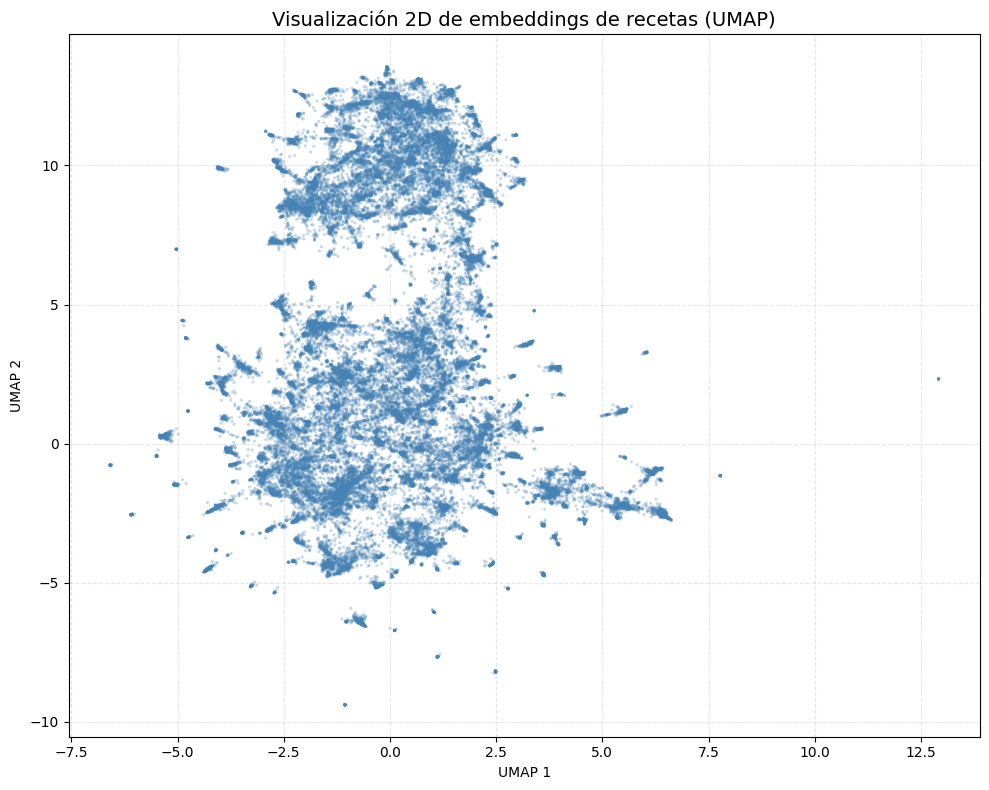

In [34]:
# =============================================================
# Visualización de los embeddings reducidos con UMAP
# =============================================================

# Ajusto el tamaño de los puntos (más pequeño = menos solapamiento)
# Transparencia (menor = más fácil ver densidad)
plt.figure(figsize=(10, 8))
plt.scatter(
    df['umap_x'],
    df['umap_y'],
    s=5,         
    alpha=0.3,    
    c='steelblue',
    edgecolors='none'
)

plt.title("Visualización 2D de embeddings de recetas (UMAP)", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(r'../Visualizaciones/embeddings_reducidos_con_UMAP.png', dpi=300)
plt.show()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> <strong>sobre qué datos realizar el clustering</strong>: 
    ¿sobre los datos reducidos en 2D o sobre los embeddings originales en alta dimensionalidad?
  <p>
    Justifica tu elección explicando las posibles consecuencias de aplicar el algoritmo 
    de clustering sobre una representación reducida en comparación con la original.
  </p>
</div>

La **elección correcta para el clustering** es hacerlo sobre los **embeddings originales** de alta dimensionalidad, no sobre la versión reducida en 2D. Esta decisión es clave para obtener un agrupamiento que sea verdaderamente representativo del significado de los textos.

La razón principal radica en la **preservación de la información semántica** y el propósito fundamental de cada técnica:

* **Embeddings Originales (384D):** Contienen la **estructura semántica completa** que el modelo ha aprendido. Al hacer el *clustering* sobre estas 384 dimensiones, el algoritmo (como `K-Means` o `HDBSCAN`) está agrupando los textos basándose en su **significado real** y sus relaciones de similitud precisas. Esto resulta en una **alta precisión** del *clustering*.
* **Embeddings Reducidos por UMAP (2D):** UMAP es una técnica de reducción de dimensionalidad **no lineal** cuyo propósito principal es la **visualización y exploración de patrones**. Aunque es excelente para dibujar los datos, en el proceso **pierde parte de la información global y distorsiona algunas distancias**. Por lo tanto, si se agrupase sobre la versión 2D, el algoritmo estará trabajando con una **proyección aproximada**, lo que puede llevar a límites de clusters distorsionados o incorrectos.

En resumen, para un análisis riguroso y una visualización clara, el flujo de trabajo recomendado es:

1.  **Fase de Clustering:** Utiliza los **embeddings originales (384D)** como entrada para tu algoritmo de clustering.
2.  **Fase de Visualización:** Una vez se tienen las etiquetas del cluster, se proyectan sobre el plano **UMAP 2D** para poder **interpretar y visualizar** los clusters y sus centroides en un gráfico fácil de entender. 

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza las recetas en su <strong>espacio original de alta dimensionalidad</strong> utilizando 
    un <strong>dendrograma</strong>. 
    Esto te permitirá analizar la estructura de los datos y comparar si las agrupaciones observadas 
    coinciden con las que aparecían en la proyección 2D de <code>UMAP</code>.
  <p>
    Comenta qué puedes inferir al observar el dendrograma:
    si existen grupos bien definidos o si las fusiones son graduales,
    y cómo se relaciona esa estructura jerárquica con las regiones que aparecían en la visualización reducida.
  </p>
</div>

El objetivo es observar cómo se agrupan las recetas en su espacio original de 384 dimensiones, sin reducir la dimensionalidad. Para ello se ha aplicado un clustering jerárquico aglomerativo, que va uniendo las recetas más parecidas de forma recursiva y genera un árbol jerárquico de fusiones que se puede visualizar mediante un dendrograma.

He optado por usar una muestra aleatoria de 30.000 recetas, ya que un dendrograma con 50.000 puntos ha sido costoso computacionalmente (más de 50 min para completar la ejecución de la celda).

In [ ]:
# =============================================================
# Visualización de la estructura jerárquica
# =============================================================

# --- Muestra una selección aleatoria (por eficiencia) ---
# (El dendrograma completo con 50.000 puntos sería ininterpretable)
n_samples = 30000  # ajusta este valor según rendimiento
sample_idx = np.random.choice(len(embeddings), n_samples, replace=False)
embeddings_sample = embeddings[sample_idx]

# --- Cálculo de la matriz de enlace (linkage matrix) ---
# 'ward' minimiza la varianza dentro de cada grupo
linkage_matrix = linkage(embeddings, method='ward')

# --- Visualización del dendrograma ---
plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',     # muestra solo las fusiones más altas
    p=30,                      # número de grupos visibles
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

plt.title("Dendrograma jerárquico de recetas (embeddings originales)")
plt.xlabel("Recetas (muestra)")
plt.ylabel("Distancia de fusión")
plt.tight_layout()
plt.savefig(r'../Visualizaciones/dendrograma_recetas.png', dpi=300)
plt.show()

Al observar el dendrograma, se aprecia que las fusiones entre recetas son mayormente graduales, sin saltos grandes de distancia. Esto indica que el espacio semántico generado por el modelo all-MiniLM-L6-v2 presenta una estructura continua, donde las recetas se distribuyen de forma progresiva más que en grupos totalmente aislados.

En comparación con la proyección 2D obtenida mediante UMAP, las regiones densas que aparecían en el plano corresponden a ramas intermedias del dendrograma, lo cual sugiere que UMAP logra preservar bien las relaciones locales, aunque tiende a enfatizar separaciones que en el espacio original son más difusas.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Dado lo observado en la reducción de dimensionalidad con <code>UMAP</code> y en el dendrograma obtenido,
    decide <strong>qué algoritmo de clustering</strong> utilizarías para identificar los grupos de recetas.
    Explica con qué argumentos lo elegirías y justifica tu respuesta en función de la estructura observada 
    en los datos (densidad, tamaño y forma de los grupos).
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Implementa el algoritmo elegido y analiza sus posibles parámetros para obtener el resultado deseado.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Representa en un <strong>scatter plot</strong> la proyección 2D (UMAP) coloreando cada punto según su
    <code>cluster</code>. Usa una paleta cualitativa rica en colores (como <code>tab20</code>). Si hay más clusters que colores disponibles, reutiliza colores
    aplicando el índice del cluster <em>módulo</em> el número de colores de la paleta.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Para interpretar el clustering y validar su coherencia, selecciona los <strong>10 grupos</strong> con mayor tamaño y muestra,
    para cada uno, las <strong>5 recetas más cercanas al centroide</strong> (si el método lo define).
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Observa los resultados del clustering e interpreta si los grupos obtenidos <strong>tienen sentido</strong> desde un punto de vista culinario. 
    Observa si las recetas dentro de un mismo cluster comparten ingredientes, estilo de preparación o tipo de plato 
    (por ejemplo, salsas, postres, carnes, ensaladas...). 
    Explica brevemente por qué crees que los clusters son o no coherentes.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Vamos a crear una nueva representación de las recetas utilizando únicamente sus <strong>ingredientes</strong>. 
    Para ello, genera una matriz <em>one-hot</em> donde cada fila representa una receta y cada columna un ingrediente distinto.
    En esta matriz, el valor será <code>1</code> si la receta contiene ese ingrediente y <code>0</code> en caso contrario.
  <p>
    Puedes utilizar la clase <code>MultiLabelBinarizer</code> de <code>sklearn.preprocessing</code> 
    para transformar automáticamente las listas de ingredientes en vectores binarios.
  </p>
  <ul>
    <li>Usa la columna de ingredientes ya procesada (listas limpias y sin valores nulos).</li>
    <li>Guarda el resultado en una nueva variable o DataFrame y asegúrate de que el número de columnas coincide con el número total de ingredientes únicos.</li>
    <li>Esta representación servirá como nueva base para aplicar técnicas de reducción de dimensionalidad y clustering.</li>
  </ul>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Aplica nuevamente <code>UMAP</code> para reducir la nueva representación <strong>one-hot de ingredientes</strong> 
    a un espacio de <strong>2 dimensiones</strong>. Esta reducción te permitirá visualizar las recetas en función de 
    la similitud de sus ingredientes y detectar posibles agrupaciones o patrones culinarios.
  <ul>
    <li>Usa los mismos parámetros de <code>UMAP</code> que antes para poder comparar visualmente ambas proyecciones.</li>
    <li>Guarda el resultado en una nueva variable con las coordenadas 2D de cada receta.</li>
  </ul>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza en un <strong>scatter plot</strong> la nueva proyección en 2D obtenida al aplicar 
    <code>UMAP</code> sobre la representación <strong>one-hot</strong> de los ingredientes. 
    Cada punto debe representar una receta, posicionada según la similitud de sus ingredientes.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Compara la visualización obtenida con los <strong>embeddings semánticos</strong> (generados con MiniLM) 
    y la nueva proyección obtenida a partir de la <strong>representación one-hot</strong> de los ingredientes.
    Describe las principales diferencias que observes entre ambas.
  </p>
  <p>
    Justifica tu respuesta planteando una <strong>hipótesis</strong> sobre por qué los puntos se organizan de forma distinta 
    en cada caso. Puedes reflexionar sobre qué tipo de información captura cada representación y cómo eso afecta a la estructura 
    de los grupos observados.
  </p>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> A partir de la nueva representación <strong>one-hot de ingredientes</strong>, decide qué 
    <strong>algoritmo de clustering</strong> utilizarías para agrupar las recetas. 
    Explica si mantendrías el mismo algoritmo usado en el caso anterior o si elegirías otro, 
    justificando tu decisión en función de la estructura observada en los datos.
  </p>
  <p>
    Si el algoritmo elegido requiere una <strong>métrica de similitud o distancia</strong>, 
    indica cuál utilizarías (por ejemplo, <em>Jaccard</em>, <em>coseno</em> o <em>euclídea</em>) 
    y argumenta por qué resulta más adecuada para este tipo de datos binarios.
  </p>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Visualiza el conjunto de datos original (la proyección 2D obtenida con <code>UMAP</code>) 
    coloreando cada punto según el <strong>cluster</strong> al que pertenece. 
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Implementación:</strong> Para interpretar el clustering y comprobar su coherencia, selecciona los <strong>10 clusters</strong> más grandes y muestra, para cada uno:
  <ol>
    <li>
      Las <strong>5 recetas más cercanas al centroide</strong> del cluster (si el método lo define). 
      Si no hay centroide, usa el <em>centroide empírico</em> (media del vector del cluster) o el <em>medoide</em> 
      (receta con menor distancia media al resto). Emplea una métrica adecuada a la representación.
    </li>
    <li>
      También, para cada cluster, muestra los <strong>ingredientes más repetidos</strong> del cluster (por ejemplo, top-3 o top-5), opcionalmente puedes indicar su frecuencia relativa
      para caracterizar el “tema” del grupo. Puedes agrupar y contar con utilidades tipo 
      <code>Counter</code> o transformaciones previas del one-hot.
    </li>
  </ol>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Analiza los resultados del clustering y valora si los <strong>clusters obtenidos tienen sentido</strong> 
    desde un punto de vista culinario. Observa los ingredientes más frecuentes y las recetas prototipo 
    de cada grupo, e identifica si existe un patrón claro que relacione los platos entre sí.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Compara los resultados obtenidos en este apartado (basados en la representación <strong>one-hot de ingredientes</strong>)
    con los del primer apartado (embeddings semánticos generados con <strong>MiniLM</strong>).
    Analiza si los grupos que aparecen son similares o diferentes, reflexiona sobre cómo influye el tipo de representación y explica las principales diferencias observadas.
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Reflexiona sobre los posibles <strong>casos de uso</strong> de los dos enfoques de clustering aplicados:
  <ul>
    <li>
      ¿Para qué tipo de problema o aplicación sería más útil el clustering basado en los 
      <strong>embeddings semánticos</strong> (MiniLM)?
    </li>
    <li>
      ¿Y en qué tipo de situación resultaría más adecuado el clustering obtenido con la 
      <strong>representación one-hot de ingredientes</strong>?
    </li>
  </ul>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Análisis:</strong> Piensa en <strong>otras maneras de generar una representación</strong> de las recetas, distintas de las vistas en la práctica 
    (como los embeddings semánticos o los vectores one-hot de ingredientes). 
    Describe brevemente cómo construirías esa nueva representación y qué tipo de información capturaría.
</div>